# 0.0 Imports

In [1]:
import math 
import pandas as pd
import inflection
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import xgboost as xgb
import pickle

from IPython.display import Image
from matplotlib.gridspec import GridSpec
from tabulate import tabulate
from scipy import stats as ss
from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso

from boruta import BorutaPy


## 0.1 Helper Functions

In [2]:
def cross_validation (x_training, kfold, model_name, model, verbose = False ):
    mae_list = []
    mape_list = []
    rmse_list = []
    for k in reversed(range( 1, kfold+1 ) ):
        if verbose:
            print( '\nKfold Number: {}'.format( k ) )
        #start and end date for validation
        validation_start_date = x_training['date'].max() - datetime.timedelta( days= k*6*7)
        validation_end_date = x_training['date'].max() - datetime.timedelta( days= (k-1)*6*7)

        #filtering dataset
        training = x_training[x_training['date'] < validation_start_date]
        validation = x_training[ ( x_training[ 'date' ] >= validation_start_date) & (x_training['date'] <= validation_end_date)]

        #training and validation dataset
        #training
        xtraining = training.drop([ 'date', 'sales' ], axis=1 )
        ytraining = training['sales']

        #validation
        xvalidation = validation.drop( [ 'date', 'sales' ], axis=1 )
        yvalidation = validation['sales']

        #model
        m = model.fit( xtraining, ytraining )

        #prediction
        yhat = m.predict(xvalidation)

        #performance
        m_result = ml_error( model_name, np.expm1(yvalidation), np.expm1( yhat ) )

        #store performance of each kfold iteration
        mae_list.append( m_result[ 'MAE' ] )
        mape_list.append( m_result['MAPE' ] )
        rmse_list.append( m_result[ 'RMSE' ] )
    return pd.DataFrame( {'Model Name': model_name,
                          'MAE CV': np.round( np.mean( mae_list ), 2 ).astype( str ) + '+/-' + np.round( np.std( mae_list), 2 ).astype( str ),
                          'MAPE CV': np.round( np.mean( mape_list ), 2 ).astype( str ) + '+/-' + np.round( np.std( mape_list), 2 ).astype( str ),
                          'RMSE CV': np.round( np.mean( rmse_list ), 2 ).astype( str ) + '+/-' + np.round( np.std( rmse_list), 2 ).astype( str )}, index=[0] )

def mean_percentage_error ( y, yhat ):
    return np.mean( (( y - yhat ) / y) )

def mean_absolute_percentage_error ( y, yhat ):
    return np.mean( np.abs (( y - yhat ) / y) )

def ml_error( model_name, y, yhat ):
    mae = mean_absolute_error( y, yhat )
    mape = mean_absolute_percentage_error( y, yhat )
    rmse = np.sqrt(mean_squared_error( y, yhat ))

    return pd.DataFrame( { 'Model Name': model_name,
                           'MAE': mae,
                           'MAPE': mape,
                           'RMSE': rmse }, index=[0] )

def cramer_v(x, y):
    """
    Calcula o Cramér's V corrigido entre duas variáveis categóricas.

    O Cramér's V é uma medida de associação entre variáveis categóricas
    baseada no teste qui-quadrado (chi²). Varia de 0 a 1:
        0.0 → sem associação entre as variáveis
        1.0 → associação perfeita entre as variáveis

    A versão corrigida (bias-corrected) evita superestimação da associação
    em amostras pequenas ou tabelas com muitas categorias.

    Parâmetros:
    -----------
    x : pd.Series
        Primeira variável categórica
    y : pd.Series
        Segunda variável categórica

    Retorna:
    --------
    float
        Valor do Cramér's V corrigido entre 0 e 1
    """

    # Cria a tabela de contingência e extrai os valores como matriz numpy
    cm = pd.crosstab(x, y).values

    n = cm.sum()        # total de observações
    r, k = cm.shape     # r = nº de linhas | k = nº de colunas da tabela

    # Calcula o chi² e aplica a correção de viés (bias correction)
    # chi2_contingency retorna (chi2, p, dof, expected) — usamos apenas o [0]
    chi2 = ss.chi2_contingency(cm)[0]
    chi2corr = max(0, chi2 - (k-1)*(r-1)/(n-1))  # chi² corrigido — nunca negativo

    # Corrige k e r para amostras pequenas
    # evita superestimação quando há poucas observações por categoria
    kcorr = k - (k-1)**2 / (n-1)  # número de colunas corrigido
    rcorr = r - (r-1)**2 / (n-1)  # número de linhas corrigido

    # Calcula e retorna o Cramér's V corrigido
    # min(kcorr-1, rcorr-1) normaliza pelo menor grau de liberdade possível
    return np.sqrt((chi2corr/n) / (min(kcorr-1, rcorr-1)))

## 0.2 Loading data

In [3]:
df_sales_raw = pd.read_csv('datasets/train.csv', low_memory=False)
df_store_raw = pd.read_csv('datasets/store.csv', low_memory=False)
df_store_raw.head(20)

#merge
df_raw = pd.merge(df_sales_raw, df_store_raw, how='left', on='Store')

In [4]:
df_raw.sample()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
312791,813,6,2014-10-11,4651,533,1,0,0,0,a,a,1560.0,9.0,2003.0,0,NaN,NaN,NaN


# 1.0 DESCRICAO DOS DADOS

In [5]:
df1 = df_raw.copy()

## 1.1 Rename columns

In [6]:
cols_old = [['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
             'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
             'CompetitionDistance', 'CompetitionOpenSinceMonth',
             'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
             'Promo2SinceYear', 'PromoInterval']]

snakecase = lambda x: inflection.underscore( x )
cols_new = list(map(snakecase, cols_old[0]))

#rename
df1.columns = cols_new

## 1.2 Data Dimensions

In [7]:
print('Number of rows: {}'.format(df1.shape[0]))
print('Number of columns: {}'.format(df1.shape[1]))

Number of rows: 1017209
Number of columns: 18


## 1.3 Data Types

In [8]:
#transformou 'date' em datetime e verificou os tipos das colunas
df1['date']= pd.to_datetime(df1['date'])
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                             str
dtype: object

## 1.4 Check NA

In [9]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

## 1.5 Fillout NA

In [10]:
# competition_distance
#pegar a coluna competition_distance
#verificar se tem valor nulo
#se tiver valor nulo, substituir por 200000.0 (para simular que a loja não tem concorrência próxima)
#se não tiver valor nulo, manter o valor da coluna
df1['competition_distance'] = df1['competition_distance'].apply(lambda x: 200000.0 if math.isnan(x) else x)

# competition_open_since_month - substituir os valores nulos pelo mês da data da linha para não ter valores nulos
#pegar a coluna competition_open_since_month
#verificar se tem valor nulo
#se tiver valor nulo, substituir pelo valor do mês da data da linha 
#se não tiver valor nulo, manter o valor da coluna
df1['competition_open_since_month'] = df1.apply(lambda x: x['date'].month if math.isnan(x['competition_open_since_month']) else x['competition_open_since_month'], axis=1)

# competition_open_since_year
df1['competition_open_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['competition_open_since_year']) else x['competition_open_since_year'], axis=1)

# promo2_since_week
df1['promo2_since_week'] = df1.apply(lambda x: x['date'].week if math.isnan(x['promo2_since_week']) else x['promo2_since_week'], axis=1)

#promo2_since_year
df1['promo2_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['promo2_since_year']) else x['promo2_since_year'], axis=1)

# promo_interval
#transformou os valores nulos da coluna promo_interval em zero, para não ter valor nulo
#se a coluna promo_interval for igual a 0, então is_promo é igual a 0
#se a coluna month_map estiver presente na coluna promo_interval, então is_promo é igual a 1
#se não, is_promo é igual a 0
#criou uma coluna nova chamda is_promo, que indica se a loja está em promoção ou não, com base na coluna promo_interval e no mês da data da linha
month_map ={ 1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec' }
df1['promo_interval']=df1['promo_interval'].fillna(0)#atualizei o código, o .fillna(0, inplace=True) não funcionou bem então usei o .fillna(0) e atribui o resultado para a própria coluna promo_interval
df1['month_map'] = df1['date'].dt.month.map(month_map)
df1['is_promo']= df1[['promo_interval', 'month_map']].apply(lambda x: 0 if x['promo_interval'] == 0 else 1 if x['month_map'] in x['promo_interval'].split(',') else 0, axis=1)

## 1.6 Change Types

In [11]:
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
month_map                                  str
is_promo                                 int64
dtype: object

In [12]:
# Após preencher os valores nulos, é necessário converter as colunas necessárias para o tipo inteiro, 
# para evitar problemas futuros na análise e modelagem dos dados. As colunas que precisam ser convertidas são:
# competition_open_since_month, competition_open_since_year, promo2_since_week e promo2_since_year.
df1['competition_open_since_month'] = df1['competition_open_since_month'].astype(int)
df1['competition_open_since_year'] = df1['competition_open_since_year'].astype(int)
df1['promo2_since_week'] = df1['promo2_since_week'].astype(int)
df1['promo2_since_year'] = df1['promo2_since_year'].astype(int)

## 1.7 Descriptive Statistical

In [13]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64'])

In [14]:
num_attributes.sample(2)

,store,day_of_week,sales,customers,open,promo,school_holiday,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo
851515,441,3,8199,818,1,1,0,2530.0,5,2013,0,22,2013,0
421293,609,4,5030,531,1,1,0,2070.0,9,2007,0,25,2014,0


In [15]:
cat_attributes.sample(2)

,state_holiday,store_type,assortment,promo_interval,month_map
105149,0,a,c,0,Apr
980572,0,d,c,"Feb,May,Aug,Nov",Feb


## 1.7.1 Numerical Attributes

In [16]:
#numerical statistics
#Central Tendency - mean, median
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T #média
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T #mediana


#Dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply(np.std)).T                      #desvio padrão
d2 = pd.DataFrame(num_attributes.apply(min)).T                         #min
d3 = pd.DataFrame(num_attributes.apply(max)).T                         #max
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T #range
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T          #skew
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T      #kurtosis

#Concatenar os dataframes de central tendency e dispersion
m = pd.concat([d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']

In [17]:
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


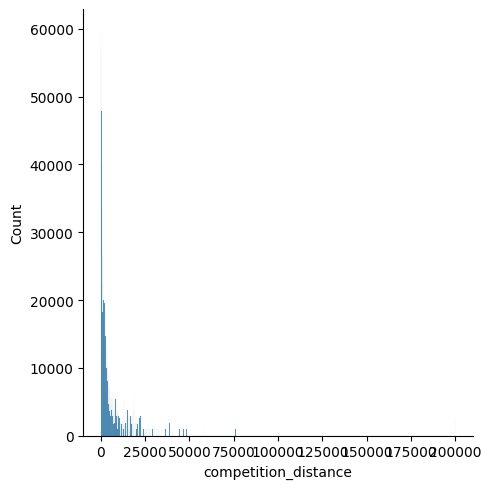

In [18]:
sns.displot(df1['competition_distance'])
plt.show()

## 1.7.2 Categorical Attributes

In [19]:
cat_attributes.apply(lambda x: x.unique().shape[0])

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

<Axes: xlabel='assortment', ylabel='sales'>

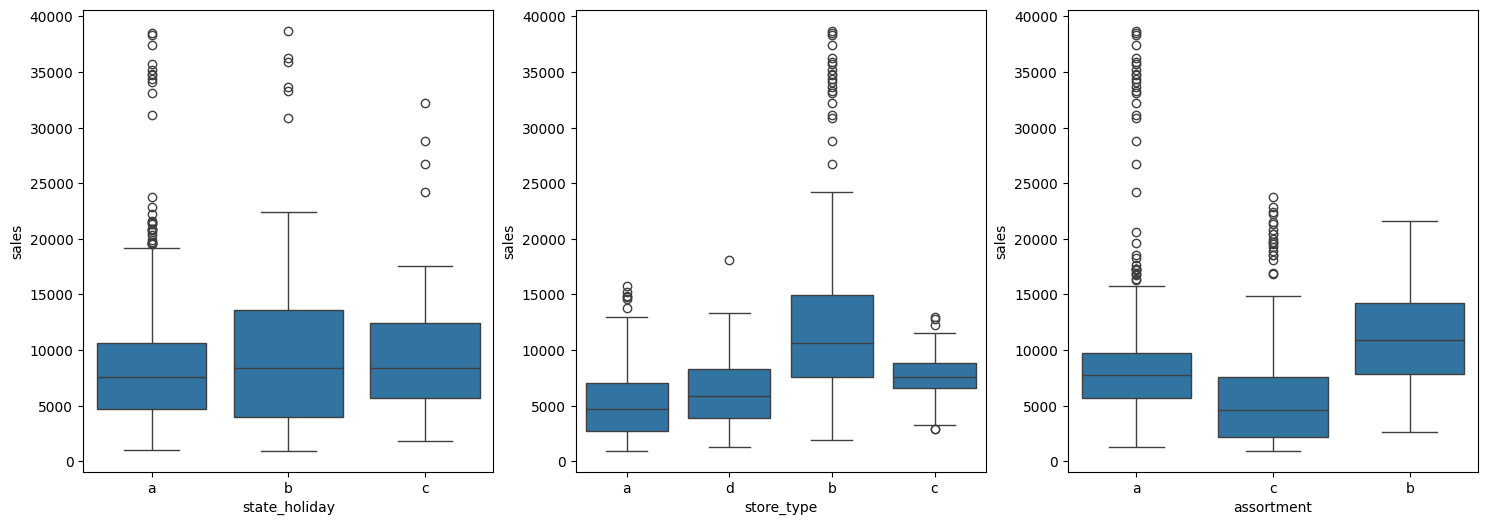

In [20]:
#boxplot
# primeiro, vamos filtrar o dataframe para considerar apenas os dias em que houve feriado e as 
# vendas foram maiores que zero, para evitar distorções na análise. 
# Em seguida, vamos criar três boxplots para analisar a relação entre as variáveis 'state_holiday', 'store_type' e 'assortment' com as vendas ('sales'). 
# Cada boxplot será criado em um subplot diferente para facilitar a visualização. O código para isso é o seguinte:
auxl = df1[(df1['state_holiday'] != '0') & (df1['sales'] > 0)]

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='state_holiday', y='sales', data=auxl)

plt.subplot(1, 3, 2)
sns.boxplot(x='store_type', y='sales', data=auxl)

plt.subplot(1, 3, 3)
sns.boxplot(x='assortment', y='sales', data=auxl)


# 2.0 FEATURE ENGINEERING

In [21]:
df2 = df1.copy()

## Mapa mental de Hipóteses

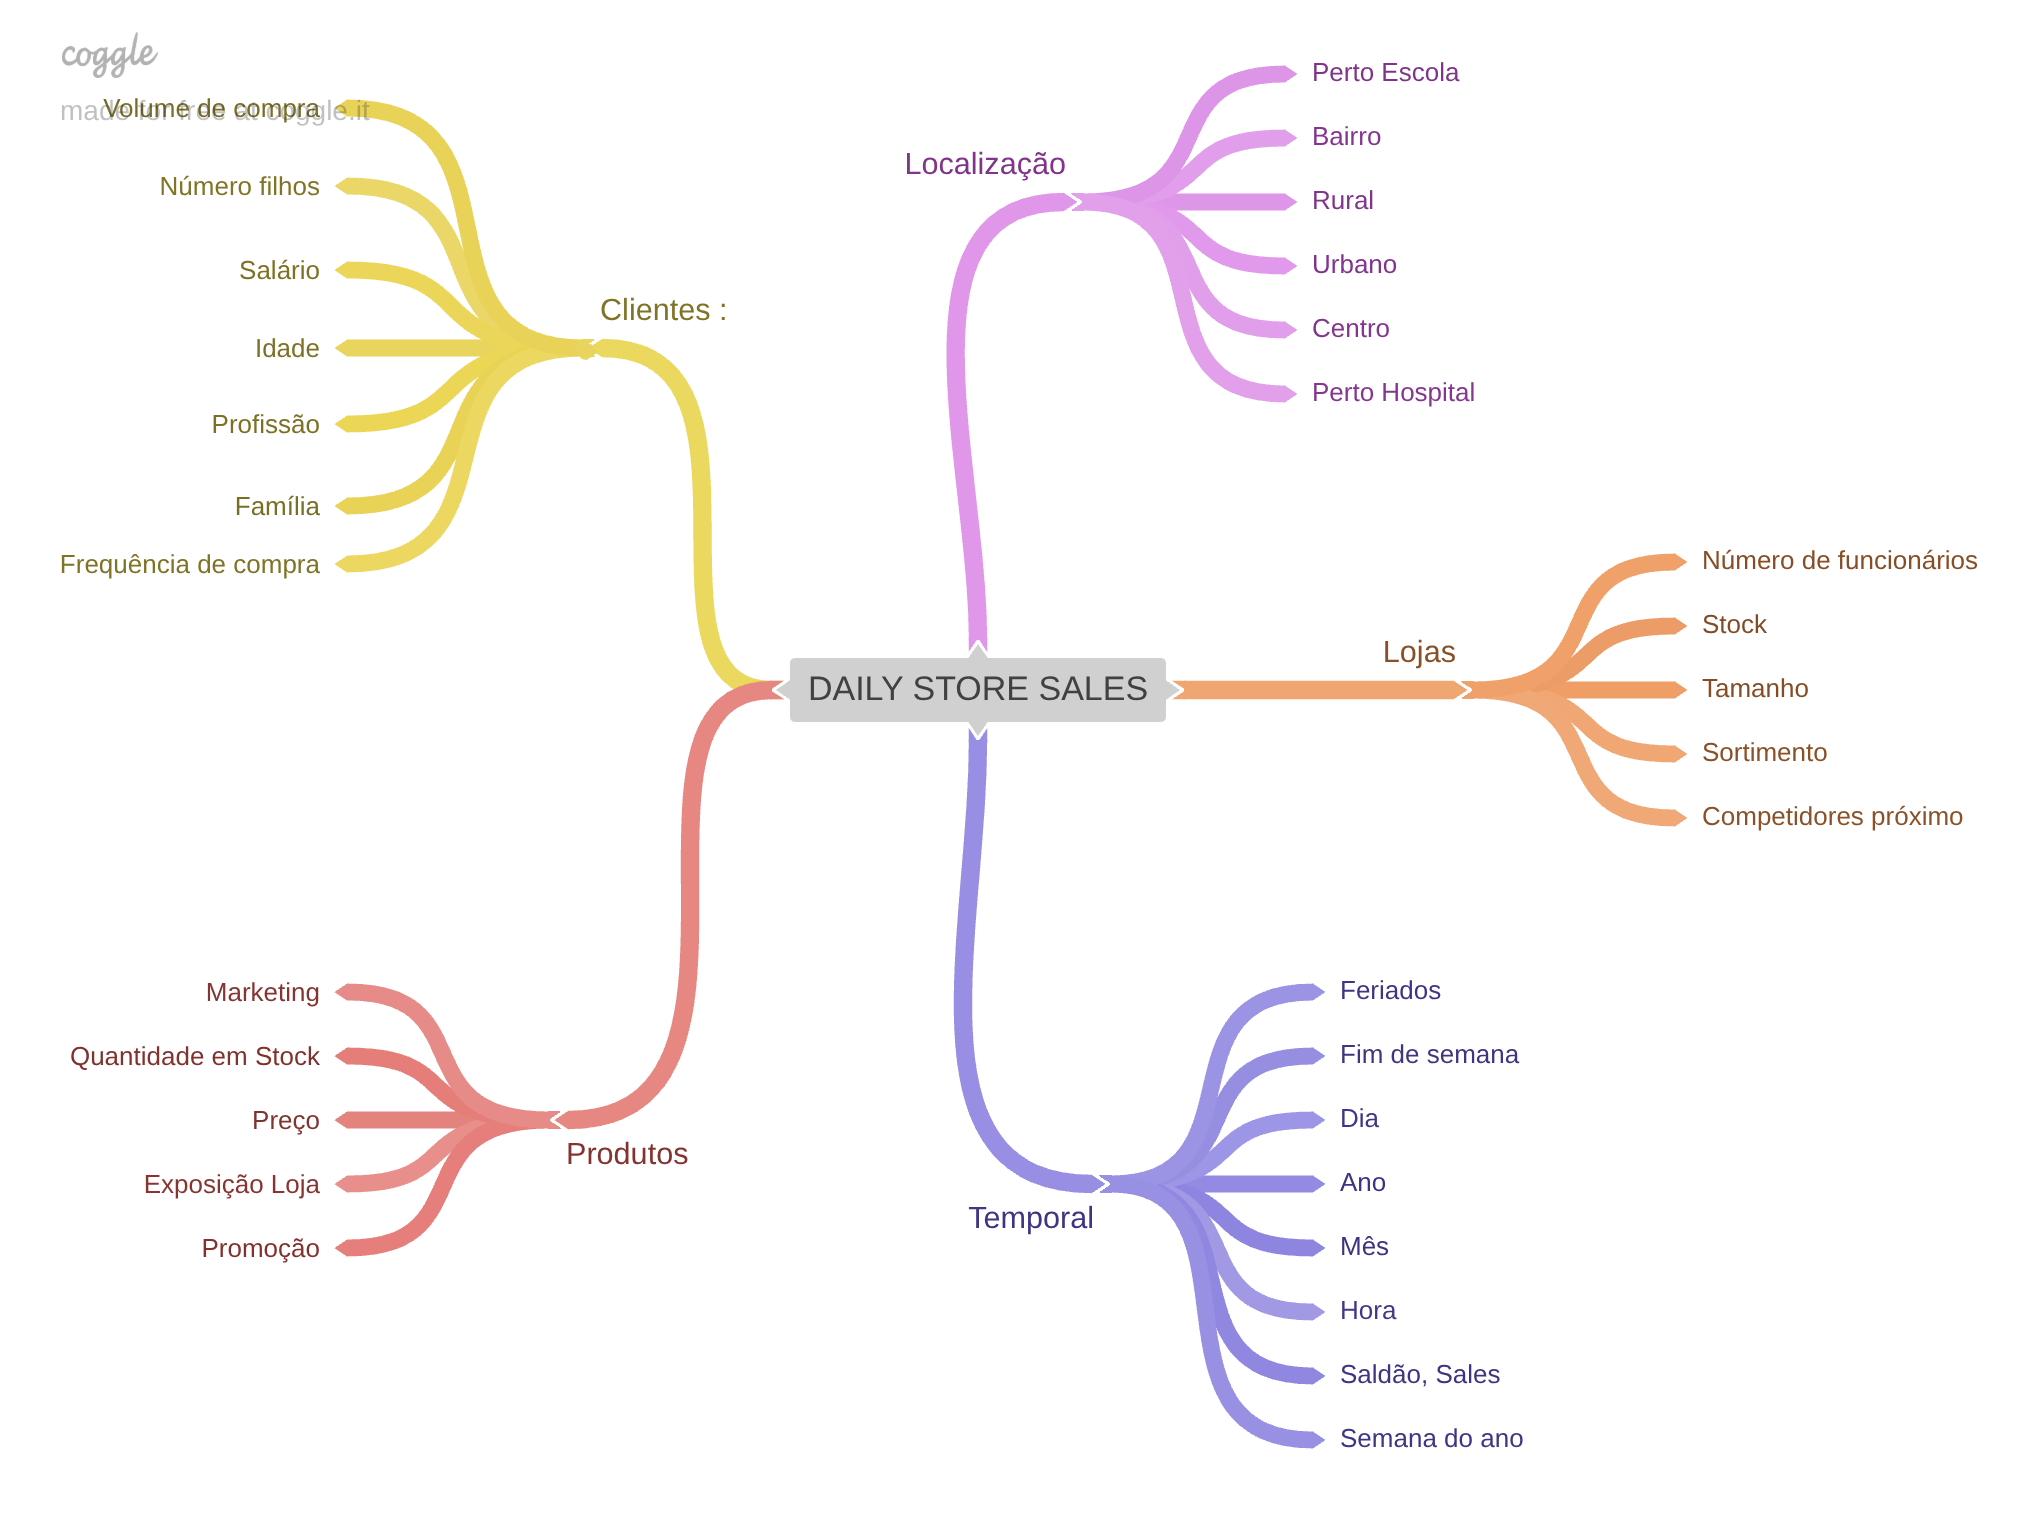

In [22]:
# Construção do mapa mental de hipóteses:
# Fenômeno: Qual fenômeno estou modelando?
# Agentes: Quem são os agentes que atuam sobre o fenômeno de interesse?
# Atributos dos agentes: que descrevem os agentes
Image('img/mind_map_hipothesis.png')

## 2.1 Criação das hipóteses

### 2.1.1 Hipóteses Loja

**1.** Lojas com maior quadro de funcionários deveriam vender mais;

**2.** Lojas com maior estoque deveriam vender mais;

**3.** Lojas com maior porte deveriam vender mais;

**4.** Lojas com menor porte deveriam vender menos;

**5.** Lojas com maior sortimento deveriam vender mais;

**6.** Lojas com competidores mais próximos deveriam vender menos;

**7** Lojas com competidores à mais tempo deveria vender mais.

### 2.1.2 Hipóteses Produto

**1.** Lojas que investem mais em Marketing deveriam vender mais;

**2.** Lojas com maior exposição dos produtos, deveriam vender mais;

**3.** Lojas que tem preços menores nos produtos, deveriam vender mais;

**4.** Lojas que tem preços menores por mais tempo, deveria vender mais;

**5.** Lojas com promoções mais agressivas(descontos maiores), deveriam vender mais;

**6.** Lojas com promoções ativas por mais tempo deveriam vender mais;

**7.** Lojas com mais dias de promoção deveriam vender mais;

**8** Lojas com mais promoções consecutivas deveriam vender mais

### 2.1.3 Hipóteses Tempo

**1.** Lojas abertas durante o feriado de Natal deveriam vender mais;

**2.** Lojas deveriam vender mais ao longo dos anos;

**3.** Lojas deveriam vender mais no segundo semestre do ano;

**4.** Lojas deveriam vender mais depois do dias 10 de cada mês.

**5.** Lojas deveriam vender menos aos finais de semana;

**6.** Lojas deveriam vender menos durante os feriados escolares

## 2.2 Lista final de Hipóteses

**1.** Lojas com maior sortimento deveriam vender mais;

**2.** Lojas com competidores mais próximos deveriam vender menos;

**3** Lojas com competidores à mais tempo deveria vender mais.

**4.** Lojas com promoções ativas por mais tempo deveriam vender mais;

**5.** Lojas com mais dias de promoção deveriam vender mais;

**6** Lojas com mais promoções consecutivas deveriam vender mais;

**7.** Lojas abertas durante o feriado de Natal deveriam vender mais;

**8.** Lojas deveriam vender mais ao longo dos anos;

**9.** Lojas deveriam vender mais no segundo semestre do ano;

**10.** Lojas deveriam vender mais depois do dias 10 de cada mês.

**11.** Lojas deveriam vender menos aos finais de semana;

**12.** Lojas deveriam vender menos durante os feriados escolares

## 2.3 Feature Engineering

In [23]:
# ── Extração de componentes da data ─────────────────────────
# Extrai ano, mês, dia e semana a partir da coluna date
# para permitir análises temporais granulares

df2['year']  = df2['date'].dt.year   # ano
df2['month'] = df2['date'].dt.month  # mês (1-12)
df2['day']   = df2['date'].dt.day    # dia do mês

# Extraçãoo da semana do ano
# dt.weekofyear foi descontinuada no pandas 2.x
# substituta: isocalendar().week (padrão ISO 8601)
df2['week_of_year'] = df2['date'].dt.isocalendar().week

# Combinação de ano e semana no formato 'YYYY-WW'
# útil para agrupamentos e análises semanais
df2['year_week'] = df2['date'].dt.strftime('%Y-%W')

# competition since
# ── Tempo desde abertura do competidor ──────────────────────
# Une as colunas competition_open_since_year e competition_open_since_month
# em uma única data (dia fixado em 1) usando datetime.datetime
df2['competition_since'] = df2.apply(lambda x: datetime.datetime(year=x['competition_open_since_year'], month = x['competition_open_since_month'], day=1 ), axis=1)

# Calcula quantos meses se passaram desde a abertura do competidor
# divide a diferença de datas por 30 para converter em meses
df2['competition_time_month'] = ((df2['date'] - df2['competition_since'])/30).apply(lambda x: x.days).astype(int)

# promo since
# ── Tempo desde início da promoção extendida (promo2) ───────
# Une promo2_since_year e promo2_since_week no formato 'YYYY-WW'
# para reconstruir a data de início da promoção
df2['promo_since'] = df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str)

# Converte a string 'YYYY-WW' para datetime
# o sufixo '-1' ancora a data na segunda-feira da semana
# subtrai 7 dias para alinhar ao início real da semana da promoção
df2['promo_since'] = df2['promo_since'].apply(lambda x: datetime.datetime.strptime(x + '-1', '%Y-%W-%w') - datetime.timedelta(days=7))

# Calcula quantas semanas se passaram desde o início da promoção
# valores positivos = promoção ativa | valores negativos = antes da promoção
df2['promo_time_week'] = ((df2['date'] - df2['promo_since'])/7).apply(lambda x: x.days).astype(int)

# ── Decodificação de variáveis categóricas ──────────────────
# Traduz os códigos originais para descrições legíveis
# facilitando interpretação e análise exploratória

# assortment: a=basic | b=extra | c=extended
# assortment
df2['assortment'] = df2['assortment'].apply(lambda x: 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended')


# state_holiday: a=feriado público | b=páscoa | c=natal | 0=dia normal
df2['state_holiday']=df2['state_holiday'].apply(lambda x: 'public_holiday' if x == 'a' else 'easter_holiday' if x == 'b' else 'christmas' if x == 'c' else 'regular_day')

In [24]:
df2.sample(5).T

,135384,731474,191934,57344,939860
store,470,820,155,480,701
day_of_week,3,6,1,3,1
date,2015-04-01 00:00:00,2013-09-14 00:00:00,2015-02-09 00:00:00,2015-06-10 00:00:00,2013-03-11 00:00:00
sales,17163,11778,5970,4549,4627
customers,1947,1172,615,621,622
open,1,1,1,1,1
promo,1,0,0,0,0
state_holiday,regular_day,regular_day,regular_day,regular_day,regular_day
school_holiday,1,0,0,0,0
store_type,a,a,d,a,d


# 3.0 FILTRAGEM DE VARIÁVEIS

In [25]:
df3 = df2.copy()

In [26]:
df3.head()

,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,...,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,555,1,1,regular_day,1,c,...,0,2015,7,31,31,2015-30,2008-09-01,84,2015-07-27,0
1,2,5,2015-07-31,6064,625,1,1,regular_day,1,a,...,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,821,1,1,regular_day,1,a,...,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1498,1,1,regular_day,1,c,...,0,2015,7,31,31,2015-30,2009-09-01,71,2015-07-27,0
4,5,5,2015-07-31,4822,559,1,1,regular_day,1,a,...,0,2015,7,31,31,2015-30,2015-04-01,4,2015-07-27,0


## 3.1 Filtragem das linhas

In [27]:
# restrinções de negócio
df3 = df3[(df3['open'] != 0) & (df3['sales'] > 0)]

## 3.2 Seleção das Colunas

In [28]:
cols_drop = ['customers', 'open', 'month_map']#'promo' foi recolocada no dataset
df3 = df3.drop(cols_drop, axis=1)

# 4.0 ANÁLISE EXPLORATÓRIA DOS DADOS - EDA

In [29]:
df4 = df3.copy()

## 4.1 Análise Univariada

### 4.1.1 Response Variable

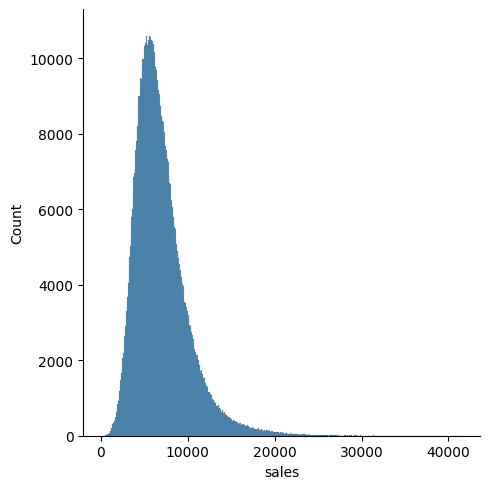

In [30]:
sns.displot(df4['sales']) #função distplot foi descontinuada, agora se chama displot

### 4.1.2 Numerical Variable 

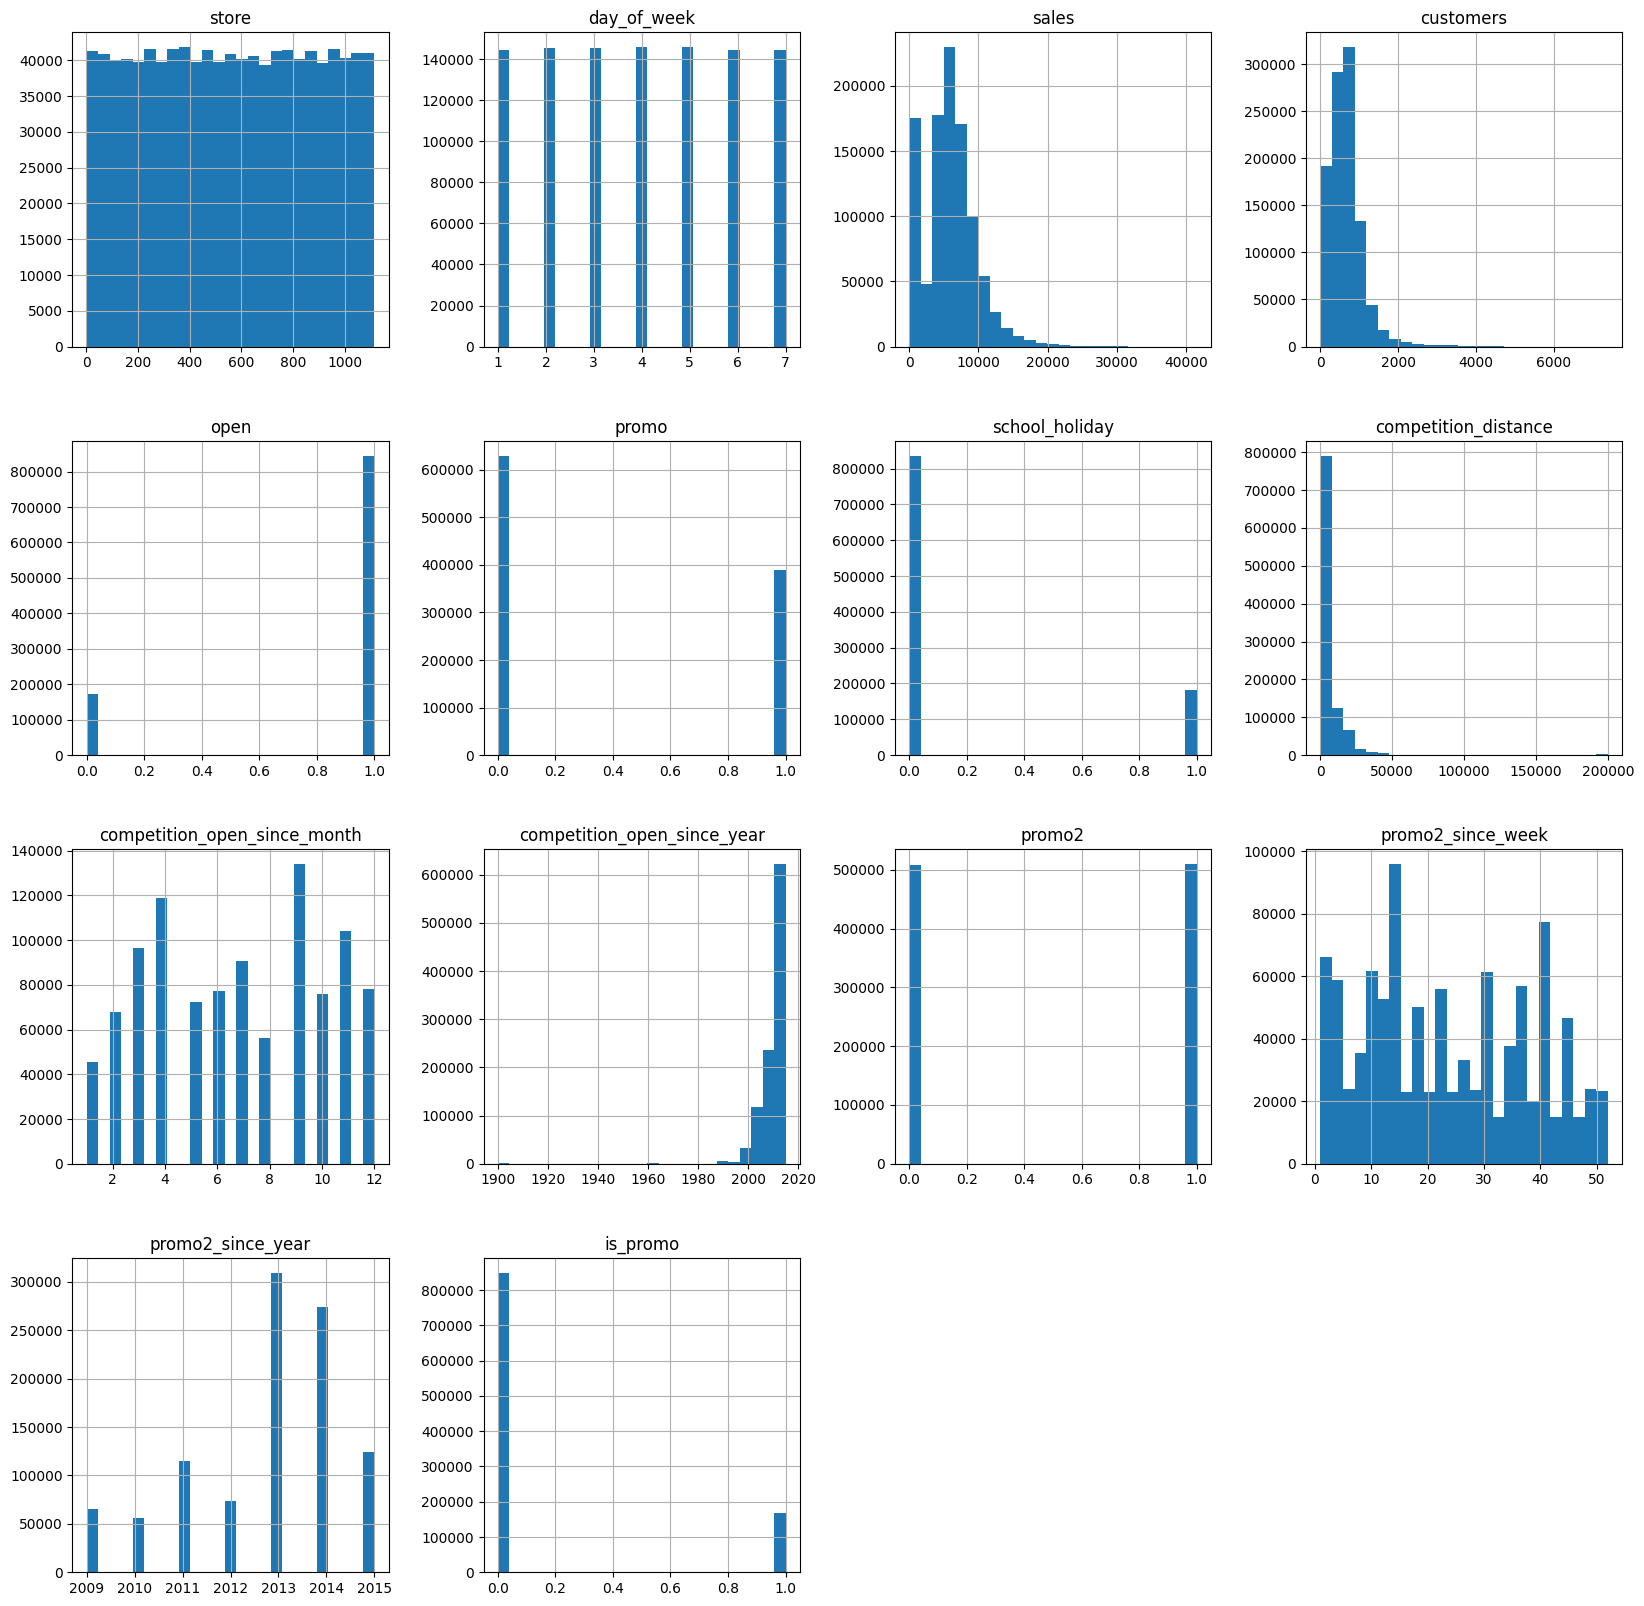

In [31]:
num_attributes.hist(bins=25, figsize=(20,20));

### 4.1.3 Categorical Variable

0            regular_day
63559     public_holiday
129424    easter_holiday
241126         christmas
Name: state_holiday, dtype: str
state_holiday
regular_day       843428
public_holiday       694
easter_holiday       145
christmas             71
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='state_holiday'>

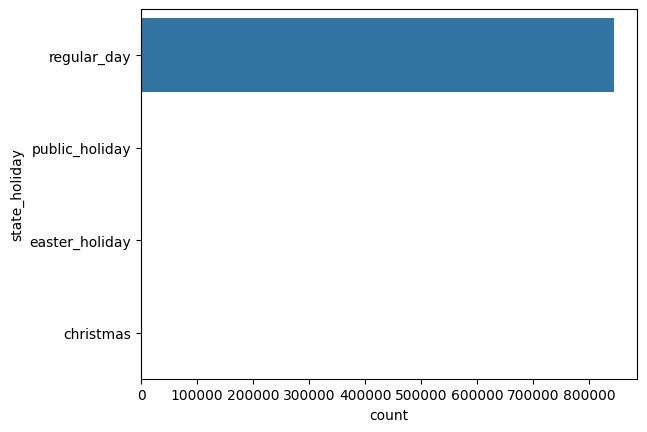

In [32]:
#Esse trecho indica que a variável state_holiday tem 4 categorias: regular_day, public_holiday, easter_holiday e christmas. A maioria dos registros são de regular_day, seguido por public_holiday, easter_holiday e christmas. O gráfico de contagem mostra que a maioria dos registros são de regular_day, seguido por public_holiday, easter_holiday e christmas. 
print(df4['state_holiday'].drop_duplicates())
print(df4['state_holiday'].value_counts())
sns.countplot(df4['state_holiday'])

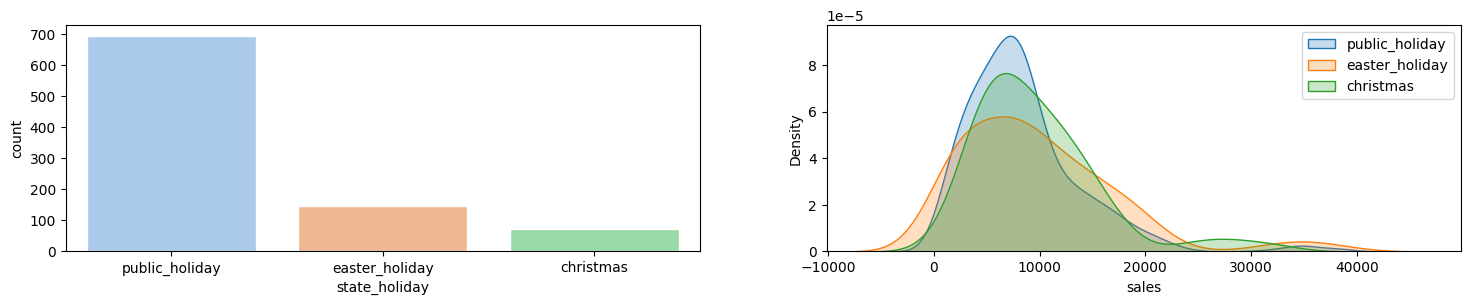

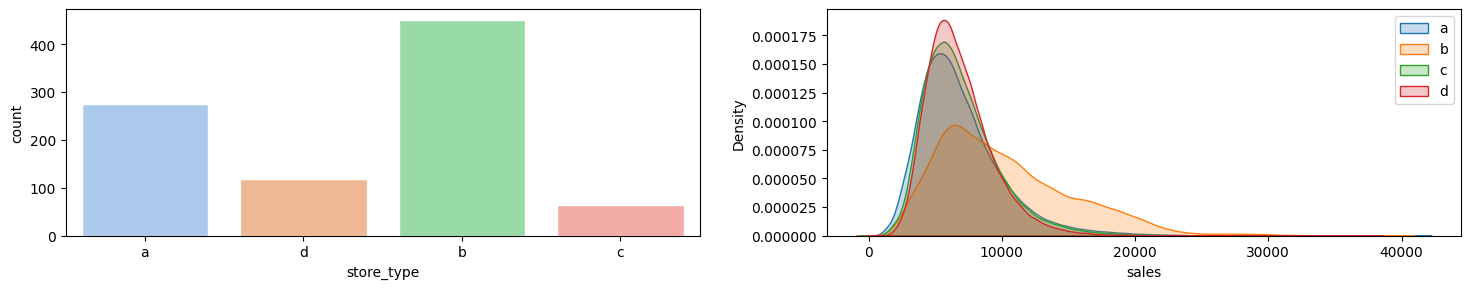

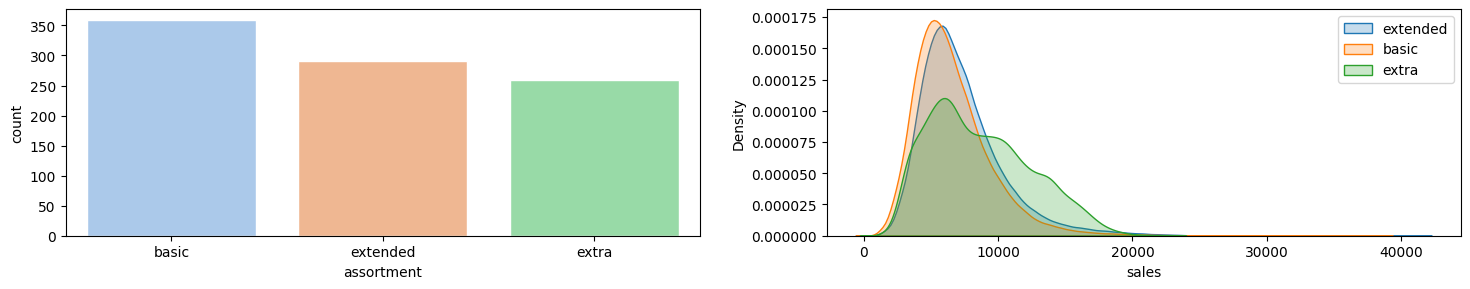

In [33]:
#state_holiday
plt.figure(figsize=(18, 10))
plt.subplot(3,2,1)
a = df4[df4['state_holiday'] != 'regular_day'] #retirando a variável regular_day da análise, para focar apenas nos feriados
#sns.countplot(a['state_holiday'])  ## esse código funciona, mas tem um warning de que a função countplot está depreciada
sns.countplot(data=a, x='state_holiday',
              hue='state_holiday',
              legend=False,
              palette='pastel',
              edgecolor='white')
#gráfico de densidade para analisar o pico da distribuição das vendas nos dias de feriado state_holiday
plt.subplot(3,2,2)
sns.kdeplot(df4[df4['state_holiday'] == 'public_holiday']['sales'], label='public_holiday', fill=True)
sns.kdeplot(df4[df4['state_holiday'] == 'easter_holiday']['sales'], label='easter_holiday', fill=True)
sns.kdeplot(df4[df4['state_holiday'] == 'christmas']['sales'], label='christmas', fill=True)
plt.legend()
plt.show()

#store_type
plt.figure(figsize=(18, 10))
plt.subplot(3,2,3)
#sns.countplot(a['state_holiday'])  ## esse código funciona, mas tem um warning de que a função countplot está depreciada
sns.countplot(data=a, x='store_type',
              hue='store_type',
              legend=False,
              palette='pastel',
              edgecolor='white')
#gráfico de densidade para analisar o pico da distribuição das vendas nos dias de feriado state_holiday
plt.subplot(3,2,4)
sns.kdeplot(df4[df4['store_type'] == 'a']['sales'], label='a', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'b']['sales'], label='b', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'c']['sales'], label='c', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'd']['sales'], label='d', fill=True)
plt.legend()
plt.show()

#assortment
plt.figure(figsize=(18, 10))
plt.subplot(3,2,5)
#sns.countplot(a['state_holiday'])  ## esse código funciona, mas tem um warning de que a função countplot está depreciada
sns.countplot(data=a, x='assortment',
              hue='assortment',
              legend=False,
              palette='pastel',
              edgecolor='white')
#gráfico de densidade para analisar a o pico da distribuição das vendas nos dias de feriado state_holiday
plt.subplot(3,2,6)
sns.kdeplot(df4[df4['assortment'] == 'extended']['sales'], label='extended', fill=True)
sns.kdeplot(df4[df4['assortment'] == 'basic']['sales'], label='basic', fill=True)
sns.kdeplot(df4[df4['assortment'] == 'extra']['sales'], label='extra', fill=True)
plt.legend()
plt.show()

## 4.2 Análise  Bivariada

#### **H1.** Lojas com maior sortimento deveriam vender mais;
***FALSA*** Lojas com maior sortimento vendem menos

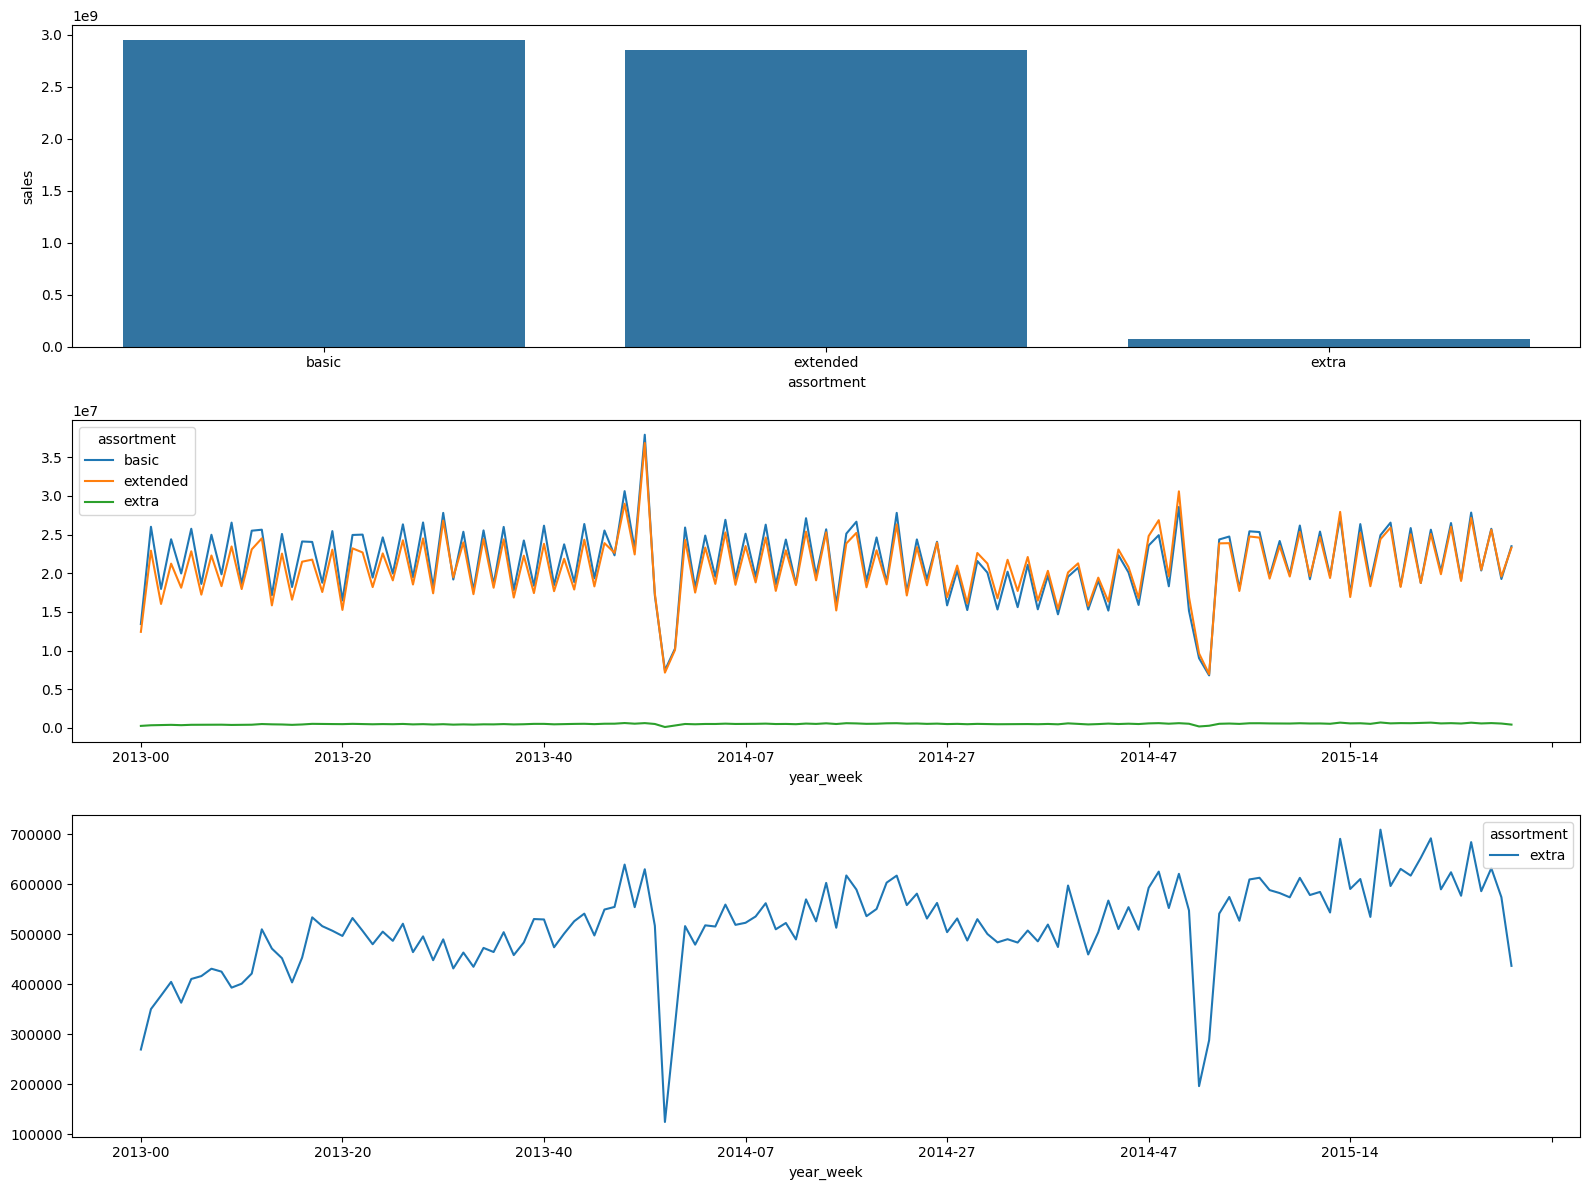

In [34]:
# Cria a figura com 3 gráficos empilhados verticalmente
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# ── Gráfico 1: Total de vendas por tipo de sortimento ───────
# Agrupa as vendas pelo tipo de sortimento (basic, extended, extra)
# e soma o total de vendas de cada categoria
aux1 = df4[['assortment', 'sales']].groupby('assortment').sum().reset_index()
# Gráfico de barras — compara o volume total de vendas por sortimento
sns.barplot(x='assortment', y='sales', data=aux1, ax=axes[0])
# ── Gráfico 2: Evolução das vendas por sortimento ao longo do tempo ──
# Agrupa as vendas por semana do ano e tipo de sortimento
# permitindo acompanhar a evolução temporal de cada categoria
aux2 = df4[['year_week', 'assortment', 'sales']].groupby(['year_week', 'assortment']).sum().reset_index()
# Pivota o DataFrame para que cada sortimento vire uma coluna
# e plota as linhas de evolução temporal lado a lado
aux2.pivot(index='year_week', columns='assortment', values='sales').plot(ax=axes[1])
# ── Gráfico 3: como o gráfico mostrou uma desproporção muito grande da categoria basic em relação às outras, 
# vamos ver mais de perto a evolução temporal das vendas da categoria extra, para entender melhor o comportamento 
# dessa categoria ao longo do tempo
aux3 = aux2[aux2['assortment']=='extra']# Pivota o DataFrame para que cada sortimento vire uma coluna
# e plota as linhas de evolução temporal lado a lado
aux3.pivot(index='year_week', columns='assortment', values='sales').plot(ax=axes[2])

plt.tight_layout()
plt.show()


A hipótese está indo no sentido falso, as lojas com o tipo de assortment extra que é o maior sortimento, está com menos vendas 

#### **H2.** Lojas com competidores mais próximos deveriam vender menos;
**FALSA** Lojas com COMPETIDORES MAIS PRÓXIMOS vendem Mais

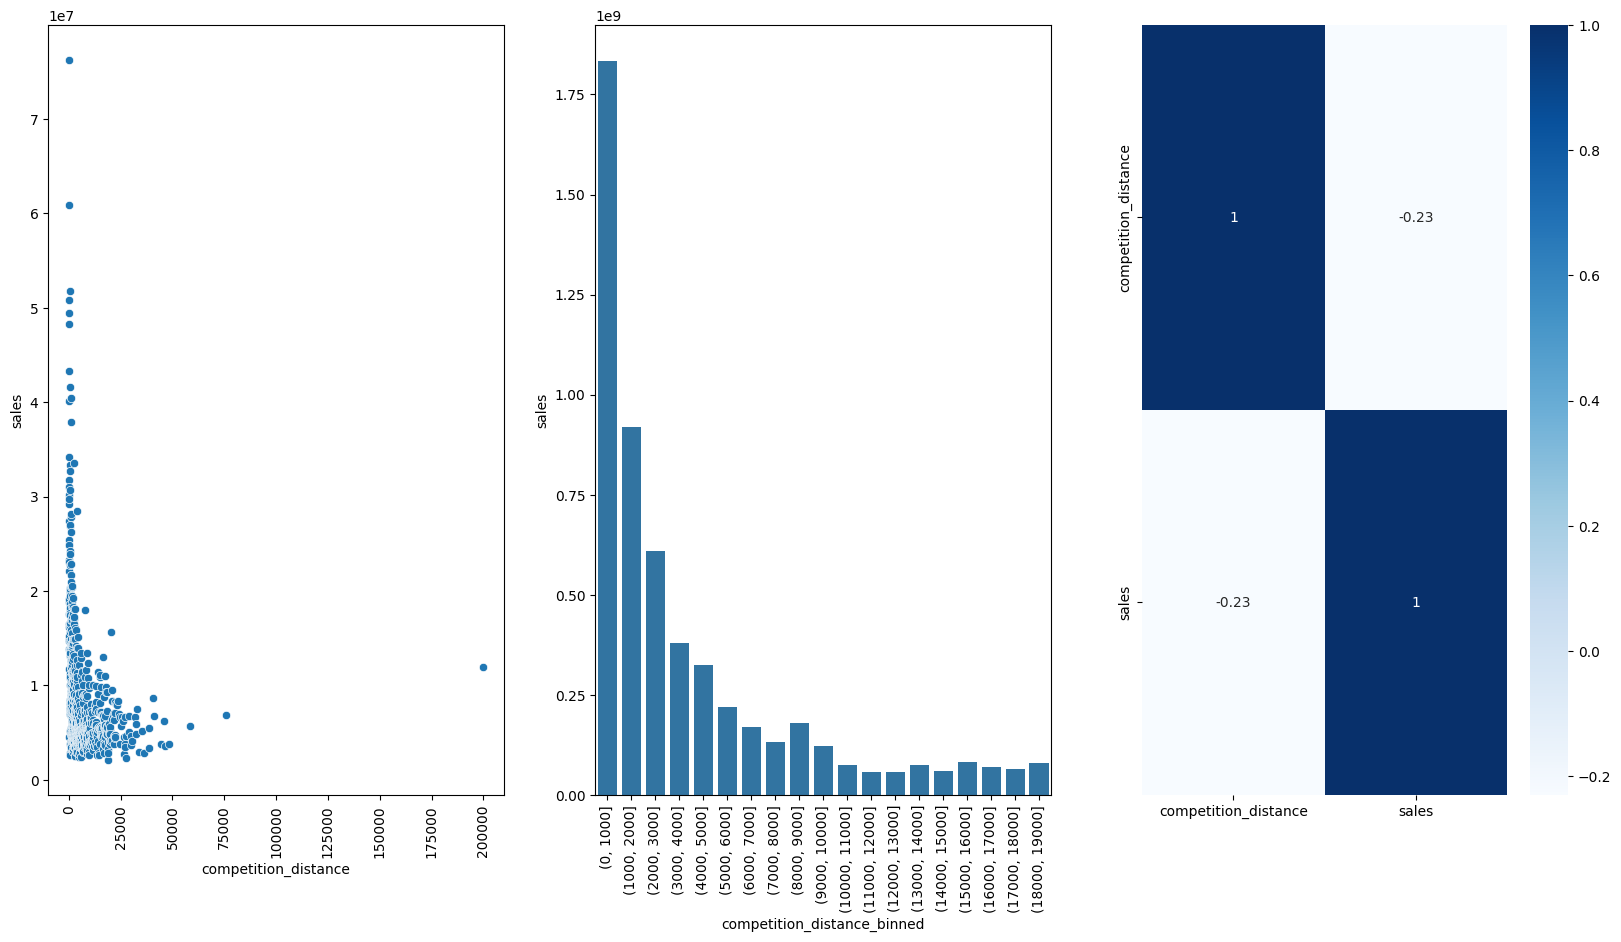

In [35]:
plt.figure(figsize=(20,10))

# ── Gráfico 1: Dispersão — distância vs vendas ──────────────
# Visualiza a relação direta entre a distância do competidor
# e o total de vendas, ponto a ponto, sem agrupamento
plt.subplot(1,3,1)
aux1 = df4[['competition_distance','sales']].groupby('competition_distance').sum().reset_index()
sns.scatterplot(x='competition_distance', y='sales', data=aux1)
plt.xticks(rotation=90);

# ── Gráfico 2: Barras — vendas por faixa de distância ───────
# Agrupa as distâncias em faixas de 1000 em 1000 metros (0 a 20km)
# pd.cut() transforma a distância contínua em categorias por intervalo
# Permite identificar em qual faixa de distância as vendas se concentram
plt.subplot(1,3,2)
bins = list(range(0, 20000,1000)) 
aux1['competition_distance_binned'] = pd.cut(aux1['competition_distance'], bins=bins)
aux2 = aux1[['competition_distance_binned', 'sales']].groupby('competition_distance_binned').sum().reset_index()
sns.barplot(x='competition_distance_binned', y='sales', data=aux2)
plt.xticks(rotation=90);

# ── Gráfico 3: Heatmap de correlação de Pearson ─────────────
# Mede numericamente a força da relação linear entre
# distância do competidor e vendas
# Valores próximos de 1 ou -1 indicam forte correlação
# Valores próximos de 0 indicam fraca ou nenhuma correlação
plt.subplot(1,3,3)
numeric_aux1 = aux1[['competition_distance','sales']]
x = sns.heatmap(numeric_aux1.corr(method='pearson'), annot=True, cmap='Blues');

#### **H3** Lojas com competidores à mais tempo deveria vender mais.
**FALSO** - Lojas com COMPETIDORES A MENOS TEMPO vendem MAIS

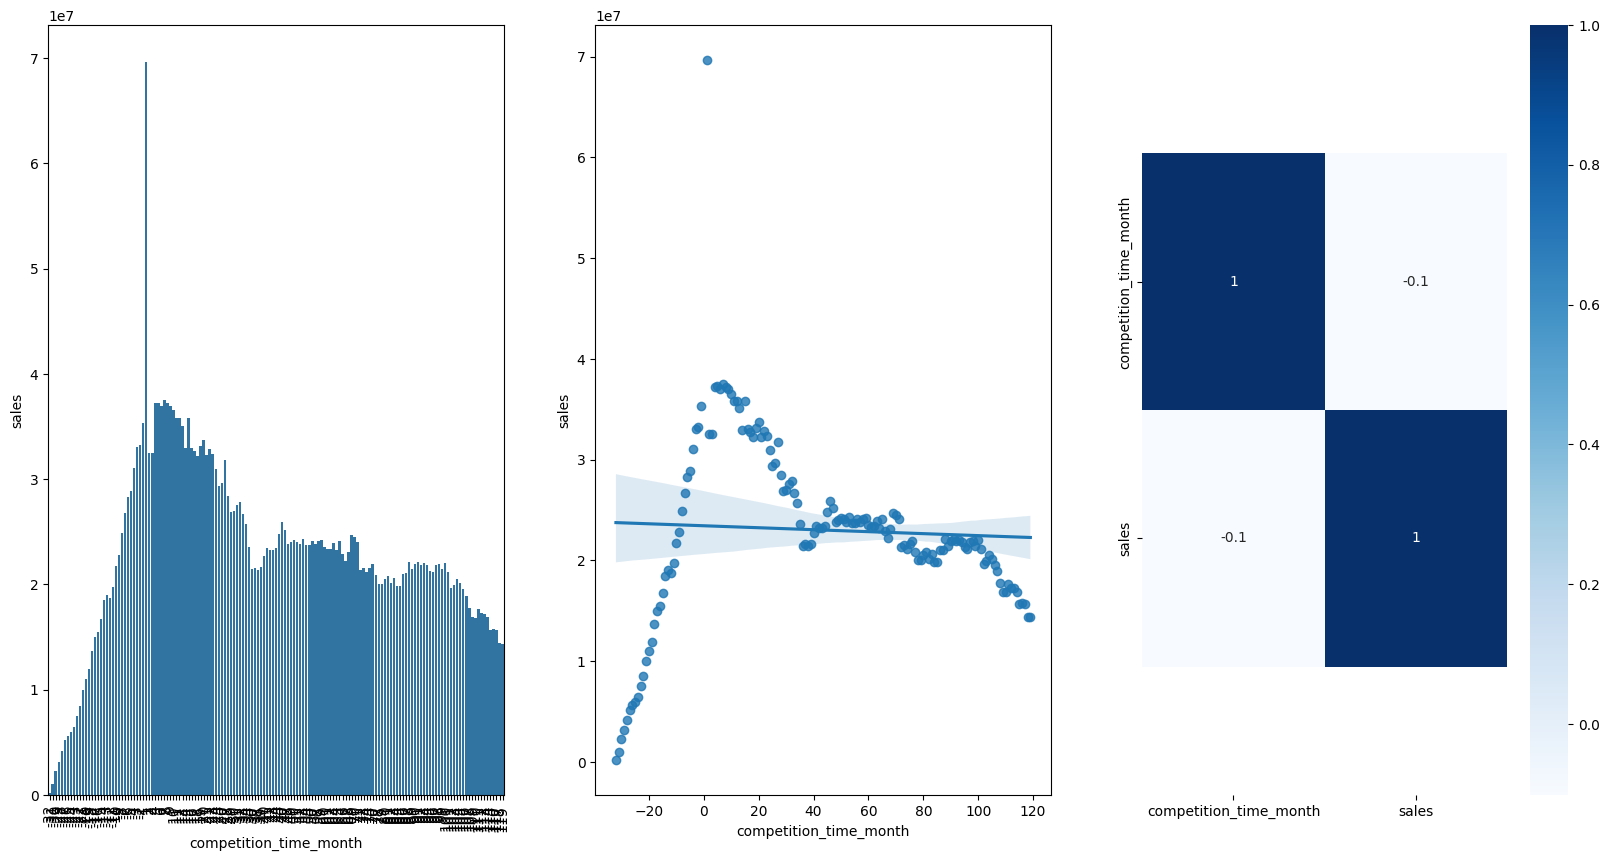

In [36]:
plt.figure(figsize=(20,10))

# ── Gráfico 1: Barras — vendas por tempo de competição ──────
# Agrupa e soma as vendas por tempo de competição em meses
# Filtra apenas lojas com competidores há menos de 120 meses (10 anos)
# e remove os casos onde o tempo é 0 (sem competidor ou dado ausente)
plt.subplot( 1 , 3 , 1 )
aux1 = df4[['competition_time_month', 'sales']].groupby('competition_time_month').sum().reset_index()
aux2 = aux1[(aux1['competition_time_month'] < 120 ) & (aux1['competition_time_month']!= 0)]
sns.barplot(x ='competition_time_month', y = 'sales', data= aux2);
plt.xticks(rotation=90);

# ── Gráfico 2: Regressão — tendência entre tempo e vendas ───
# Plota a linha de tendência linear entre o tempo de competição
# e as vendas, permitindo visualizar se há uma relação
# crescente ou decrescente ao longo do tempo
plt.subplot( 1 , 3 , 2 )
sns.regplot( x='competition_time_month', y='sales', data= aux2);

# ── Gráfico 3: Heatmap de correlação de Pearson ─────────────
# Mede numericamente a força da relação linear entre
# tempo de competição e vendas
# O ajuste de ylim corrige um bug visual do seaborn
# que corta as células do topo e do fundo do heatmap
plt.subplot( 1 , 3 , 3 )
x = sns.heatmap( aux1.corr(method = 'pearson'), annot = True, cmap='Blues');
bottom, top = x.get_ylim()
x.set_ylim(bottom+0.5, top-0.5);



### **H4.** Lojas com promoções ativas por mais tempo deveriam vender mais;
**FALSA** Lojas com promoções ativas por mais tempo vendem menos depois de um certo período de tempo

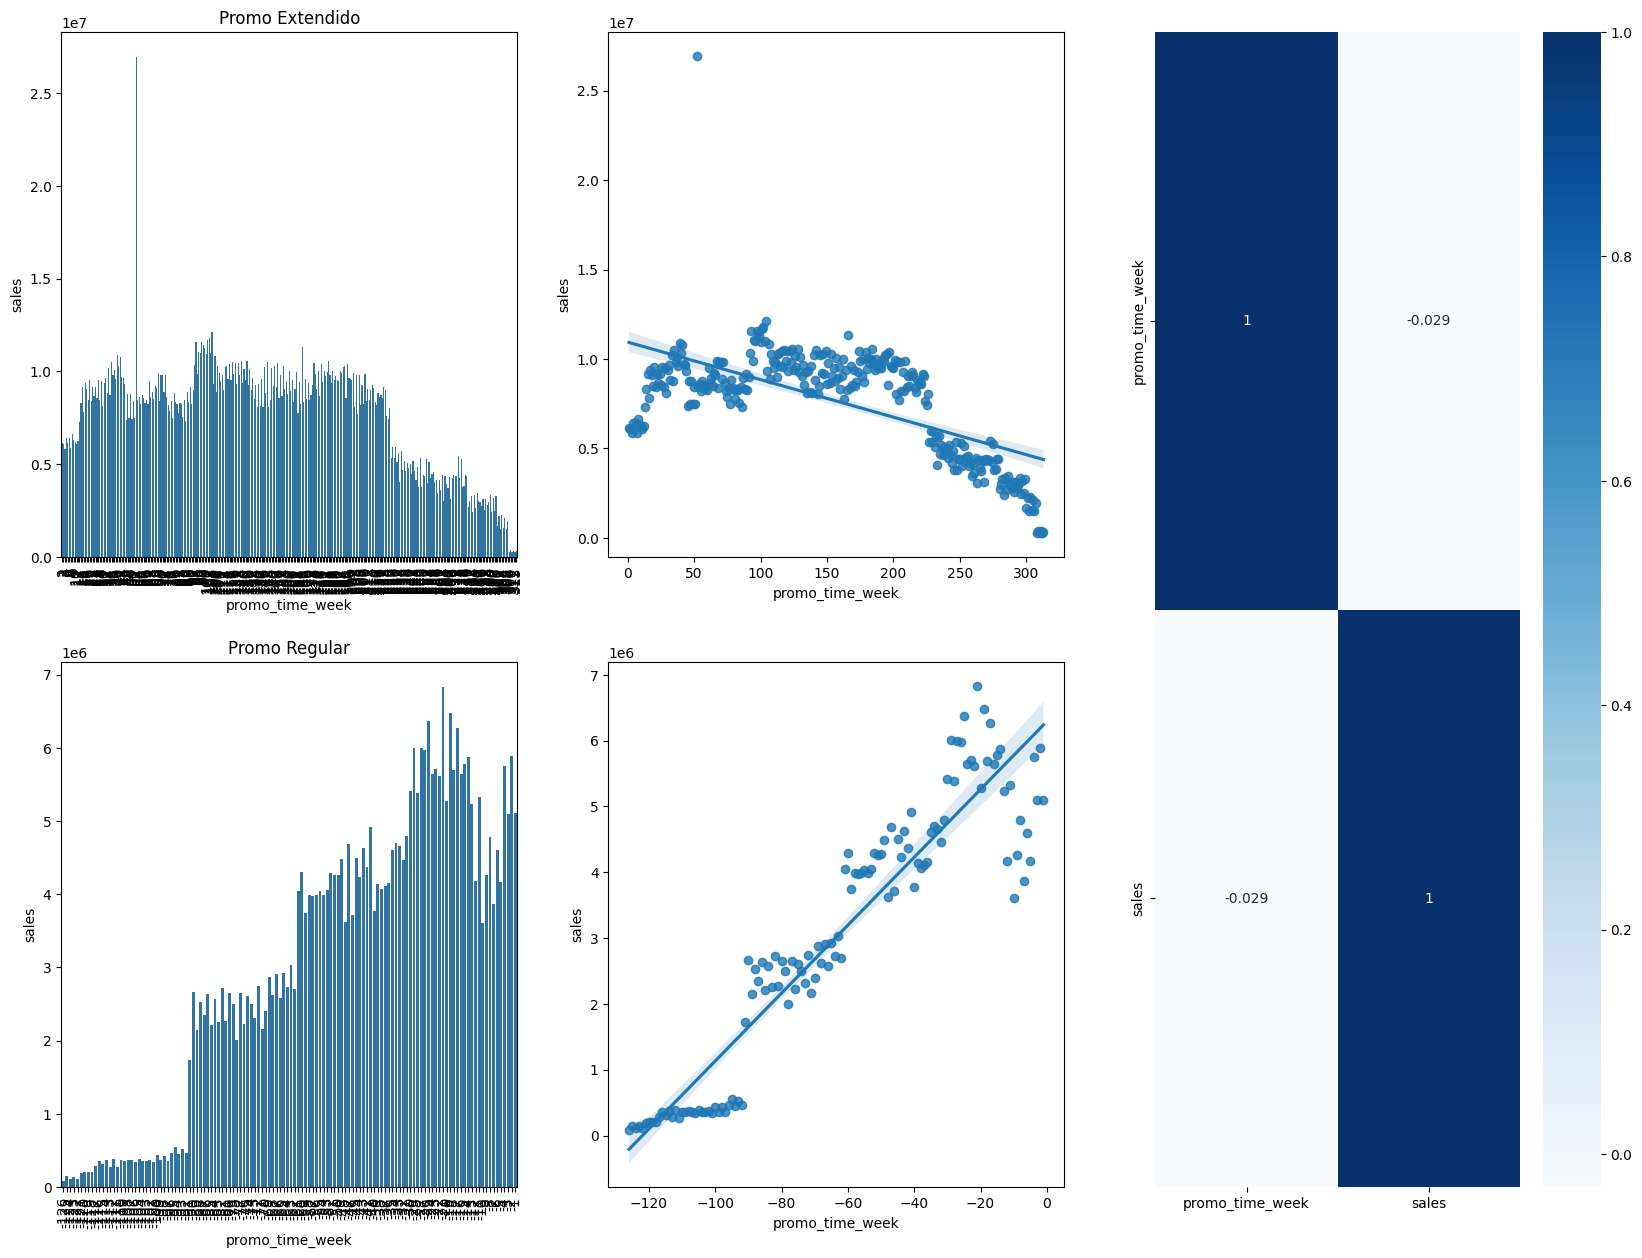

In [37]:
# Agrupa e soma as vendas por semana de promoção
# valores positivos = promo extendida | valores negativos = promo regular
aux1 = df4[['promo_time_week','sales']].groupby('promo_time_week').sum().reset_index()

# Cria a figura com grid de 2 linhas e 3 colunas
# grid[:,2] — o heatmap ocupa toda a terceira coluna (ambas as linhas)
plt.figure(figsize=(20,15))
grid = GridSpec( 2 , 3 )

# ── Linha 1: Promoção Extendida (promo_time_week > 0) ───────

# Gráfico 1: Barras — vendas por semana de promoção extendida
# Filtra apenas semanas positivas, onde a promoção está ativa há mais tempo
plt.subplot( grid[0,0] )
aux2 = aux1[aux1['promo_time_week'] > 0]
sns.barplot(x='promo_time_week', y= 'sales', data = aux2);
plt.xticks(rotation = 90)
plt.title('Promo Extendido')

# Gráfico 2: Regressão — tendência das vendas na promo extendida
# Mostra se as vendas crescem ou caem conforme a promoção se prolonga
plt.subplot( grid[0,1])
sns.regplot(x = 'promo_time_week', y='sales', data=aux2 )

# ── Linha 2: Promoção Regular (promo_time_week < 0) ─────────

# Gráfico 3: Barras — vendas por semana de promoção regular
# Filtra apenas semanas negativas, antes do início da promoção extendida
plt.subplot( grid[1,0] )
aux3 = aux1[aux1['promo_time_week'] < 0]
sns.barplot(x='promo_time_week', y= 'sales', data = aux3, );
plt.xticks(rotation=90)
plt.title('Promo Regular')

# Gráfico 4: Regressão — tendência das vendas na promo regular
# Permite comparar a inclinação da tendência com a promo extendida
plt.subplot( grid[1,1] )
sns.regplot(x = 'promo_time_week', y='sales', data=aux3 )

# ── Coluna 3: Correlação geral ───────────────────────────────

# Gráfico 5: Heatmap de correlação de Pearson
# Ocupa toda a terceira coluna (grid[:,2]) para melhor visualização
# Mede numericamente a força da relação entre tempo de promoção e vendas
plt.subplot( grid[:,2])
sns.heatmap( aux1.corr(method='pearson'), annot = True, cmap='Blues' );

plt.show()
 

### **H5.** <s>Lojas com mais dias de promoção deveriam vender mais;<s>

### **H6.** Lojas com mais promoções consecutivas deveriam vender mais
**FALSA** Lojas com mais promoções consecutivas vendem menos

In [38]:
df4[['promo', 'promo2', 'sales']].groupby(['promo', 'promo2']).sum().reset_index()


,promo,promo2,sales
0,0,0,1482612096
1,0,1,1289362241
2,1,0,1628930532
3,1,1,1472275754


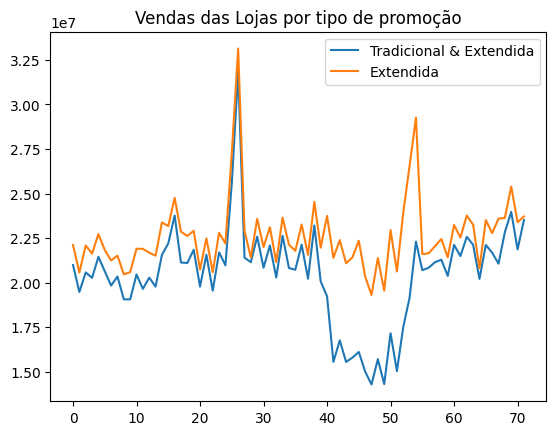

In [39]:
# ── Série 1: Lojas com promo tradicional E extendida ────────
# Filtra lojas que estão participando dos dois tipos de promoção
# agrupa por semana e soma as vendas
aux1 = df4[(df4['promo'] == 1) & (df4['promo2'] == 1)][['year_week', 'sales']].groupby('year_week').sum().reset_index()
ax = aux1.plot()  # cria o eixo base que será compartilhado com o próximo gráfico

# ── Série 2: Lojas com promo tradicional SEM extendida ──────
# Filtra lojas que participam apenas da promoção tradicional
# agrupa por semana e soma as vendas
aux2 = df4[(df4['promo'] == 1) & (df4['promo2'] == 0)][['year_week', 'sales']].groupby('year_week').sum().reset_index()
aux2.plot(ax=ax)  # ax=ax garante que as duas séries aparecem no mesmo gráfico

# ── Legenda ──────────────────────────────────────────────────
# Identifica cada linha no gráfico para facilitar a comparação visual
# entre os dois grupos de promoção ao longo do tempo
ax.legend(labels=['Tradicional & Extendida', 'Extendida'])
plt.title('Vendas das Lojas por tipo de promoção');

### **7.** Lojas abertas durante o feriado de Natal deveriam vender mais;
**FALSA** Lojas abertas durante o feriado de Natal vendem menos

Text(0.5, 1.0, 'Vendas por ano e por tipo de feriado')

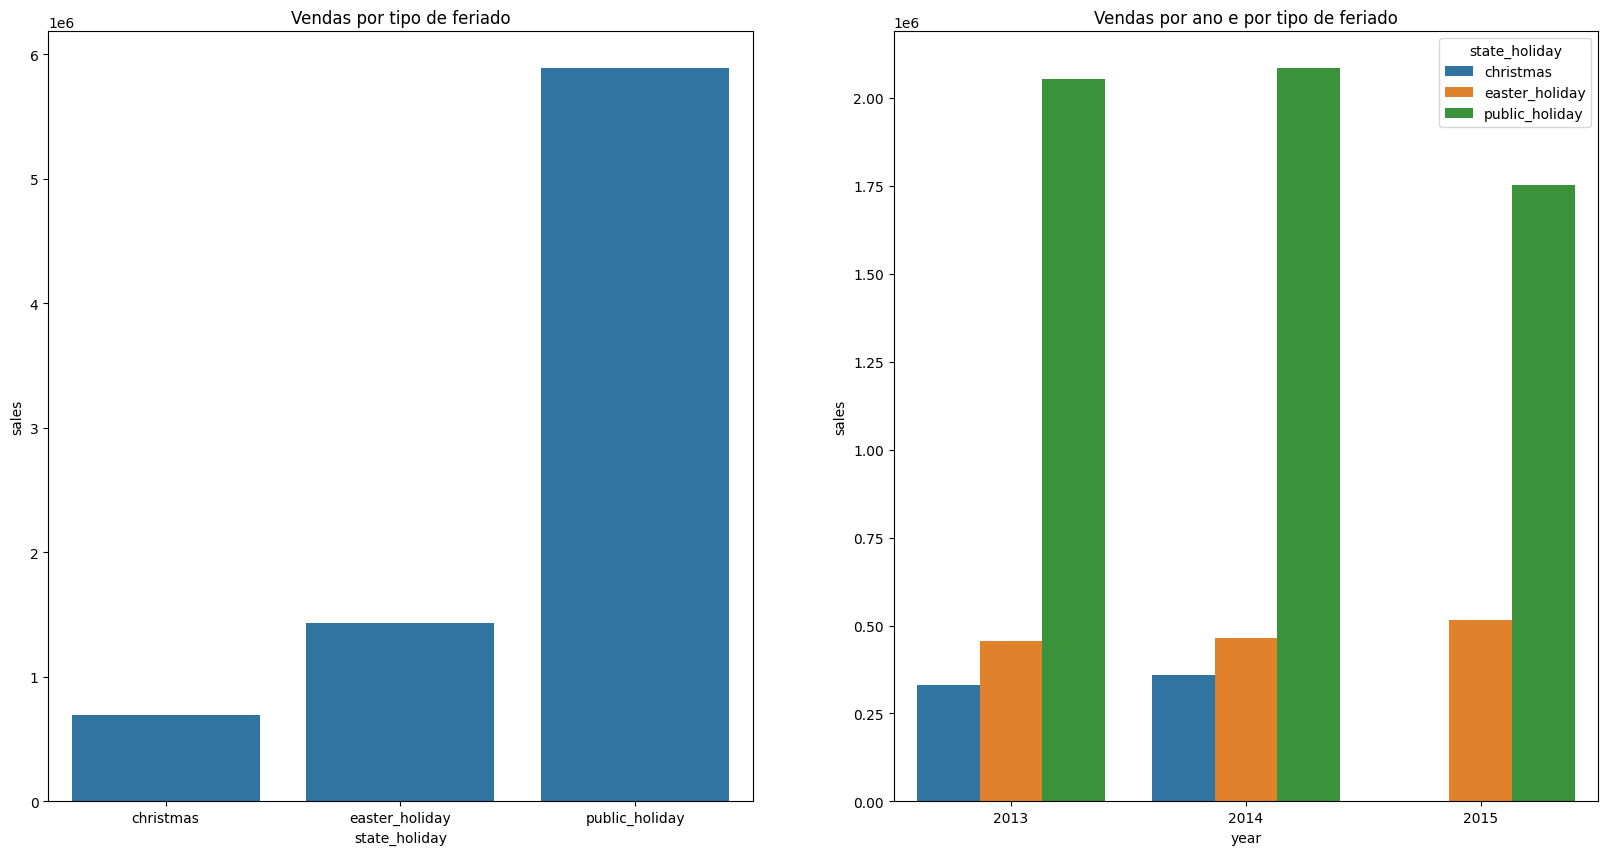

In [40]:
# Remove os dias regulares para focar apenas nos feriados
# (public_holiday, easter_holiday, christmas)
aux = df4[df4['state_holiday'] != 'regular_day']

plt.figure(figsize=(20,10))

# ── Gráfico 1: Vendas totais por tipo de feriado ────────────
# Agrupa e soma as vendas por tipo de feriado
# permite comparar o volume total de vendas em cada ocasião
plt.subplot( 1 , 2 , 1 )
aux1 = aux[['state_holiday', 'sales']].groupby('state_holiday').sum().reset_index()
sns.barplot( x='state_holiday', y='sales', data = aux1 )
plt.title('Vendas por tipo de feriado')

# ── Gráfico 2: Vendas por ano e por tipo de feriado ─────────
# Agrupa as vendas por ano e tipo de feriado simultaneamente
# o hue='state_holiday' separa as barras por tipo dentro de cada ano
# permite identificar tendências ao longo dos anos por tipo de feriado
plt.subplot( 1 , 2 , 2 )
aux2 = aux[['year','state_holiday', 'sales']].groupby(['year','state_holiday']).sum().reset_index()
sns.barplot( x='year', y='sales', hue='state_holiday', data = aux2 )
plt.title('Vendas por ano e por tipo de feriado')

Text(0.5, 1.0, 'Média de vendas por tipo de feriado')

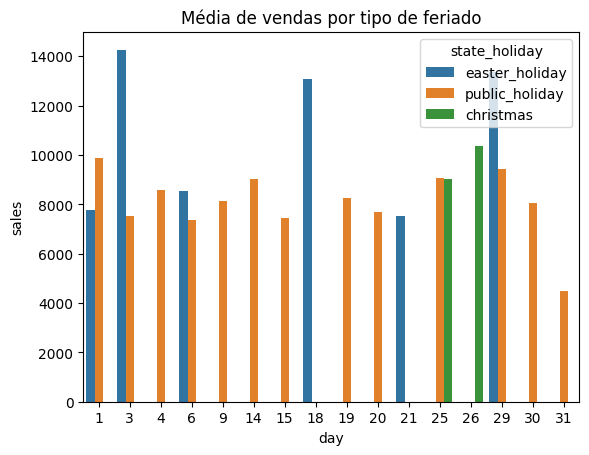

In [41]:
# Agrupa as vendas nos feriados pela média das vendas por dias, para entender quais os tipode de feriados vendem mais
aux3 = aux[['state_holiday', 'sales','day']].groupby(['day', 'state_holiday']).mean().reset_index()

sns.barplot( x='day', y='sales', hue='state_holiday', data = aux3 )
plt.title('Média de vendas por tipo de feriado')

### **H8.** Lojas deveriam vender mais ao longo dos anos;
**FALSA** Lojas vendem menos ao longo dos anos

<Axes: >

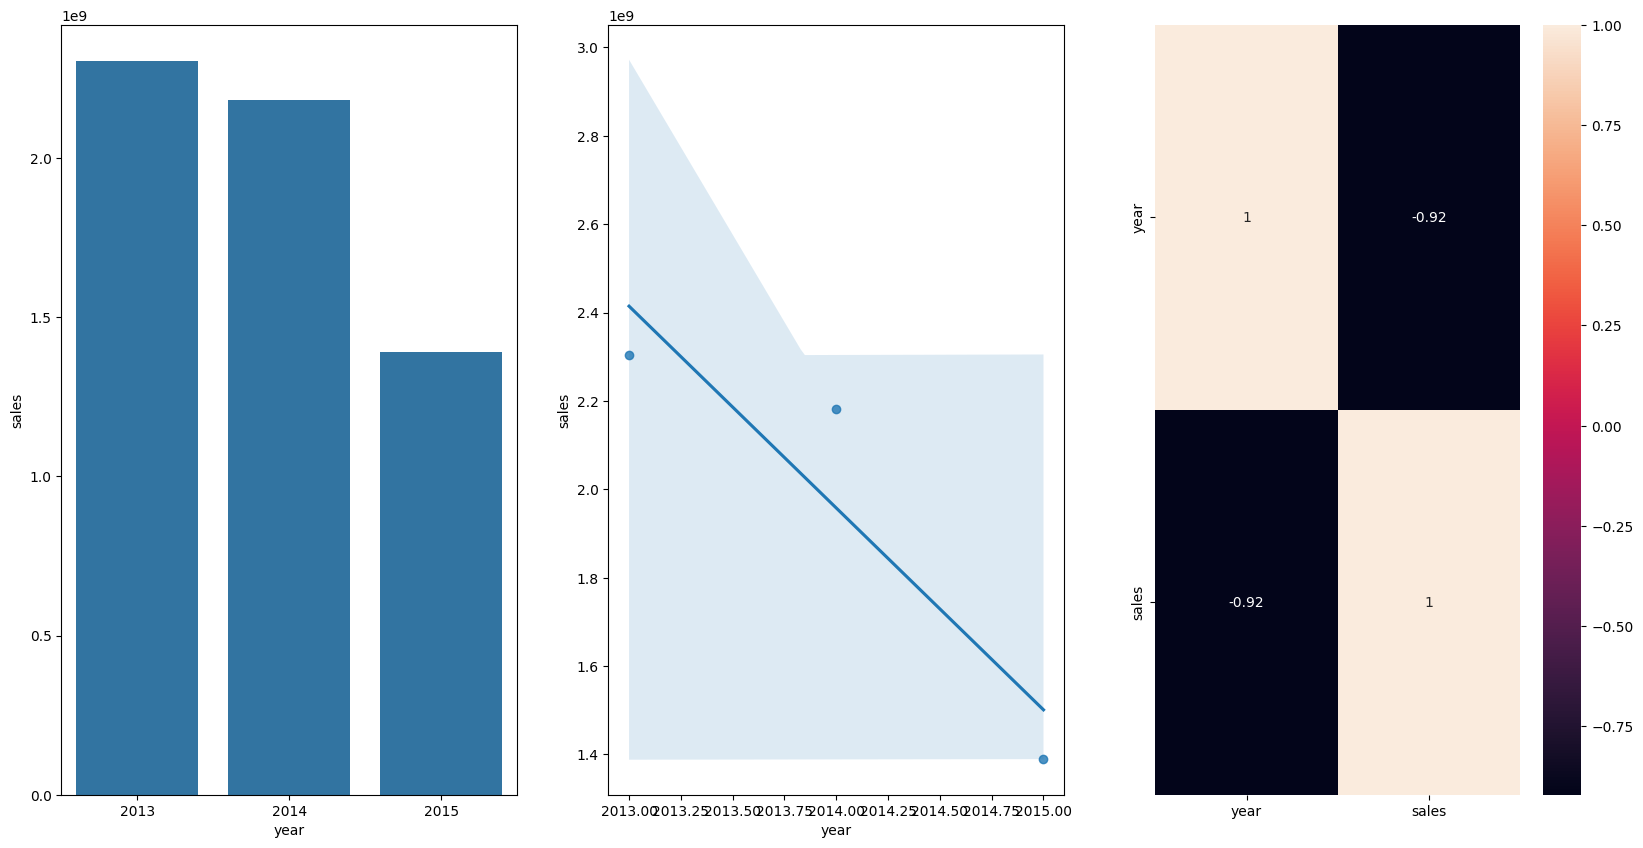

In [42]:
# Agrupa e soma as vendas por ano
aux1 = df4[['year', 'sales']].groupby('year').sum().reset_index()
plt.figure(figsize=(20,10))

# ── Gráfico 1: Barras — volume total de vendas por ano ──────
# Compara o total de vendas de cada ano diretamente
plt.subplot( 1 , 3 , 1 )
sns.barplot(x='year', y='sales', data = aux1 );

# ── Gráfico 2: Regressão — tendência das vendas ao longo dos anos ──
# Traça a linha de tendência linear para indicar se as vendas
# estão crescendo, estagnadas ou caindo ao longo do tempo
plt.subplot( 1 , 3 , 2 )
sns.regplot(x='year', y= 'sales', data = aux1);

# ── Gráfico 3: Heatmap de correlação de Pearson ─────────────
# Quantifica numericamente a força da relação entre ano e vendas
# valor próximo de 1 indica forte crescimento ao longo dos anos
# valor próximo de 0 indica que o ano não influencia as vendas
plt.subplot( 1 , 3 , 3 )
sns.heatmap(aux1.corr(method='pearson'), annot=True)

### **H9.** Lojas deveriam vender mais no segundo semestre do ano;
**FALSO Lojas vendem menos no segundo semesrte

<Axes: >

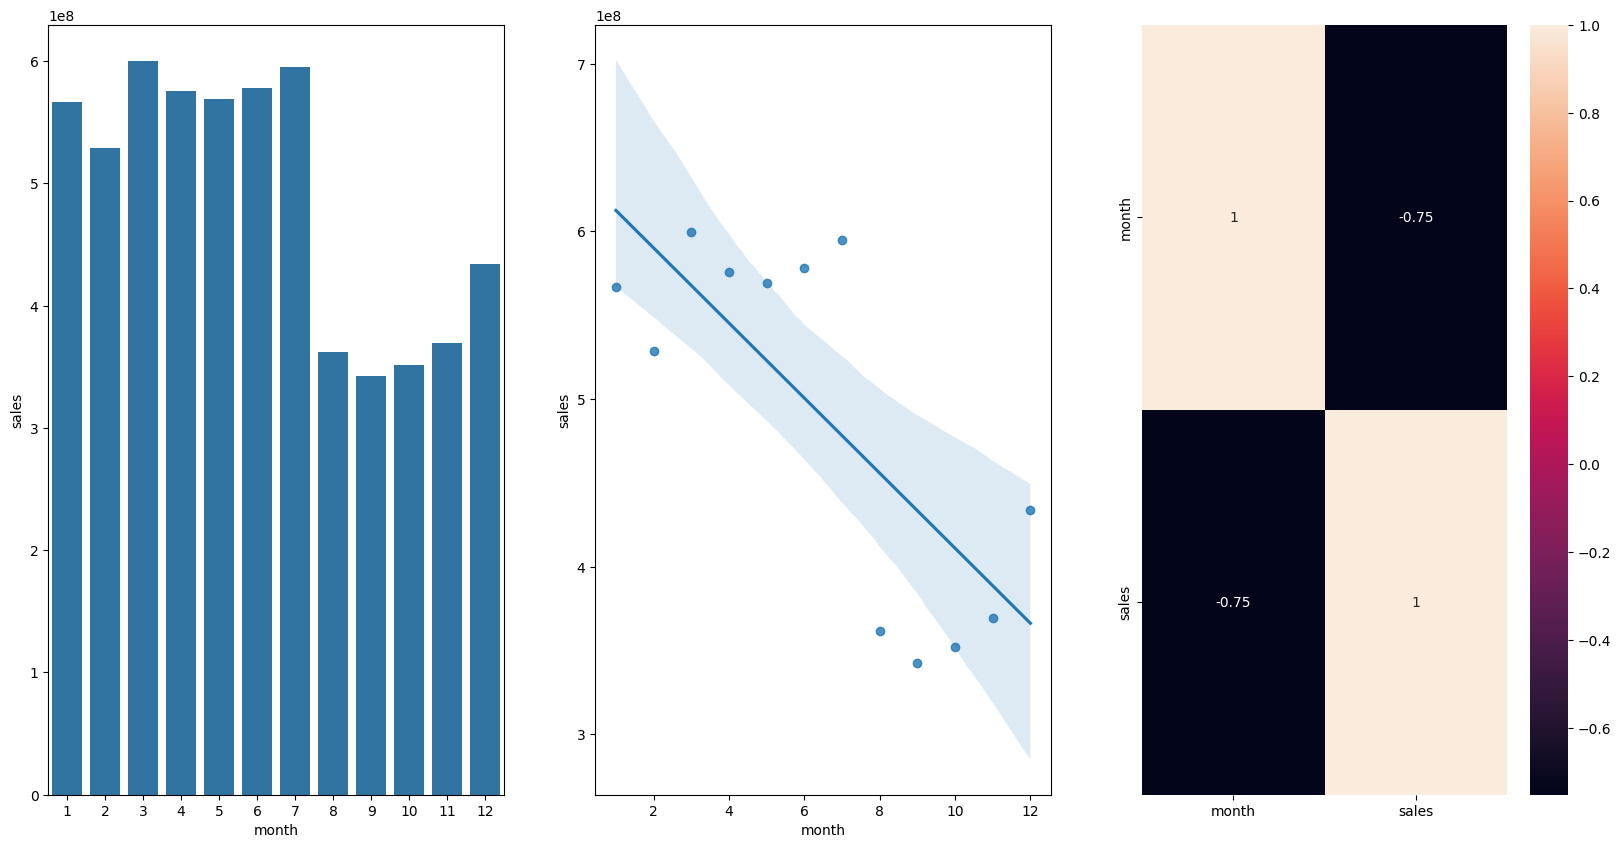

In [43]:
# Agrupa e soma as vendas por mês
aux1 = df4[['month', 'sales']].groupby('month').sum().reset_index()
plt.figure(figsize=(20,10))

# ── Gráfico 1: Barras — volume total de vendas por mês ──────
# Compara o total de vendas de cada ano diretamente
plt.subplot( 1 , 3 , 1 )
sns.barplot(x='month', y='sales', data = aux1 );

# ── Gráfico 2: Regressão — tendência das vendas ao longo dos meses ──
# Traça a linha de tendência linear para indicar se as vendas
# estão crescendo, estagnadas ou caindo ao longo do tempo
plt.subplot( 1 , 3 , 2 )
sns.regplot(x='month', y= 'sales', data = aux1);

# ── Gráfico 3: Heatmap de correlação de Pearson ─────────────
# Quantifica numericamente a força da relação entre meses e vendas
# valor próximo de 1 indica forte crescimento ao longo dos anos
# valor próximo de 0 indica que o ano não influencia as vendas
plt.subplot( 1 , 3 , 3 )
sns.heatmap(aux1.corr(method='pearson'), annot=True)

### **H10.** Lojas deveriam vender mais depois do dias 10 de cada mês.
**VERDADEIRA** Lojas vendem mais depois do dia 10 de cada mês

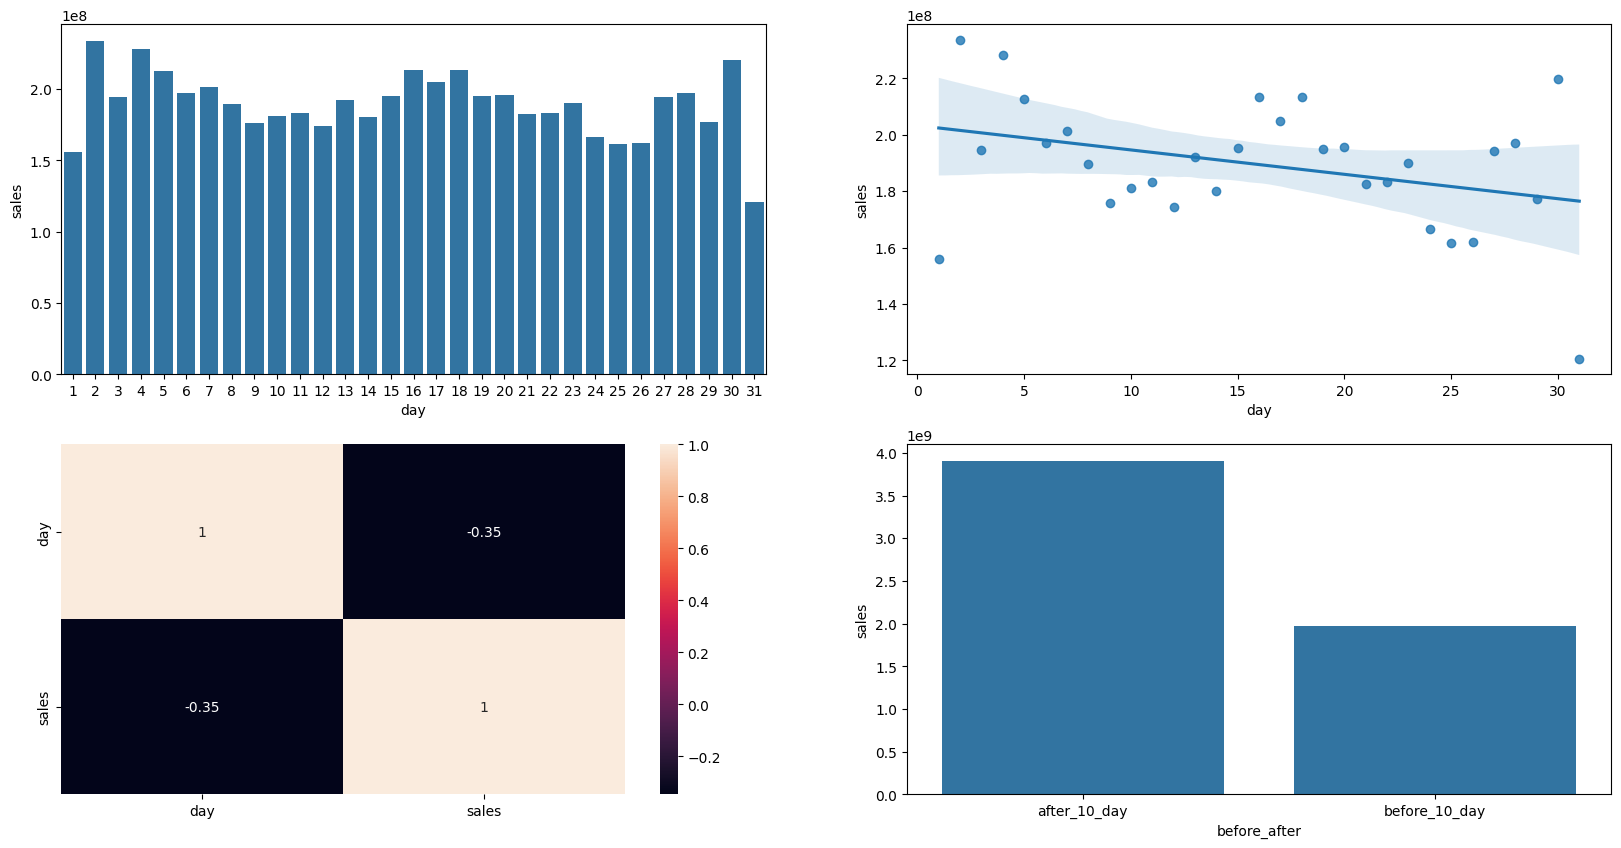

In [44]:
# Agrupa e soma as vendas diariamente
aux1 = df4[['day', 'sales']].groupby('day').sum().reset_index()
plt.figure(figsize=(20,10))

# ── Gráfico 1: Barras — volume total de vendas por dia──────
# Compara o total de vendas de cada dia ao longo do mês
plt.subplot( 2 , 2 , 1 )
sns.barplot(x='day', y='sales', data = aux1 );

# ── Gráfico 2: Regressão — tendência das vendas ao longo dos dias ──
# Traça a linha de tendência linear para indicar se as vendas
# estão crescendo, estagnadas ou caindo ao longo do tempo
plt.subplot( 2 , 2 , 2 )
sns.regplot(x='day', y= 'sales', data = aux1);

# ── Gráfico 3: Heatmap de correlação de Pearson ─────────────
# Quantifica numericamente a força da relação entre dias e vendas
# valor próximo de 1 indica forte crescimento ao longo dos dias
# valor próximo de 0 indica que o dia não influencia as vendas
plt.subplot( 2 , 2 , 3 )
sns.heatmap(aux1.corr(method='pearson'), annot=True)

# ── Gráfico 4: Barras - dias antes e depois do dia 10 ─────────────
# Foi criada uma coluna 'before_after' em aux1, e criada uma função lambda para chamar de 'before_10_day'
# quando a coluna 'day' possue valores menores que 10 e um número maior que 10 em 'after_10_day'
# foi somada a quantidade de vezes que se repetem 'before_10_day' e 'after_10_day' em 'before_after', para então montar o gráfico de barras
aux1['before_after'] = aux1['day'].apply( lambda x: 'before_10_day' if x<= 10 else 'after_10_day' )
aux2 = aux1[['before_after','sales']].groupby('before_after').sum().reset_index()
plt.subplot( 2 , 2 , 4 )
sns.barplot(x='before_after', y= 'sales', data = aux2);

### **H11.** Lojas deveriam vender menos aos finais de semana.
**VERDADEIRA** Lojas vendem menos nos fins de semana

<Axes: >

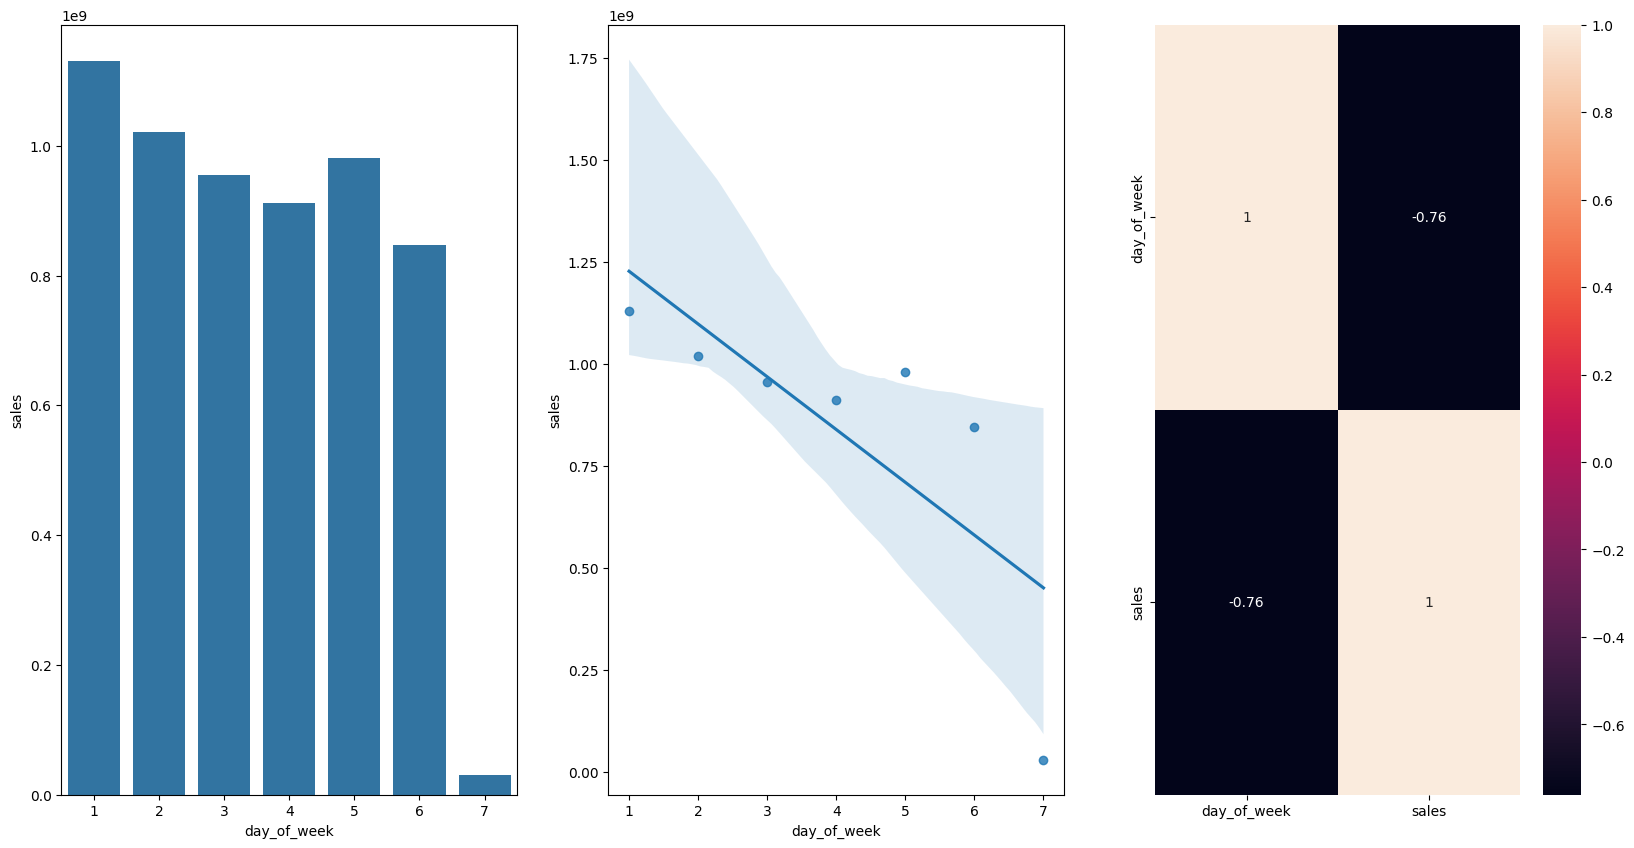

In [45]:
# Agrupa e soma as vendas por ano
aux1 = df4[['day_of_week', 'sales']].groupby('day_of_week').sum().reset_index()
plt.figure(figsize=(20,10))

# ── Gráfico 1: Barras — volume total de vendas por ano ──────
# Compara o total de vendas de cada ano diretamente
plt.subplot( 1 , 3 , 1 )
sns.barplot(x='day_of_week', y='sales', data = aux1 );

# ── Gráfico 2: Regressão — tendência das vendas ao longo dos anos ──
# Traça a linha de tendência linear para indicar se as vendas
# estão crescendo, estagnadas ou caindo ao longo do tempo
plt.subplot( 1 , 3 , 2 )
sns.regplot(x='day_of_week', y= 'sales', data = aux1);

# ── Gráfico 3: Heatmap de correlação de Pearson ─────────────
# Quantifica numericamente a força da relação entre ano e vendas
# valor próximo de 1 indica forte crescimento ao longo dos anos
# valor próximo de 0 indica que o ano não influencia as vendas
plt.subplot( 1 , 3 , 3 )
sns.heatmap(aux1.corr(method='pearson'), annot=True)

### **H12.** Lojas deveriam vender menos durante os feriados escolares
**VERDADEIRA** Lojas vendem menos durante os feriados escolares, com crescimento nos meses de julho e agosto(em agosto a hipóteses é falsa)

<Axes: xlabel='month', ylabel='sales'>

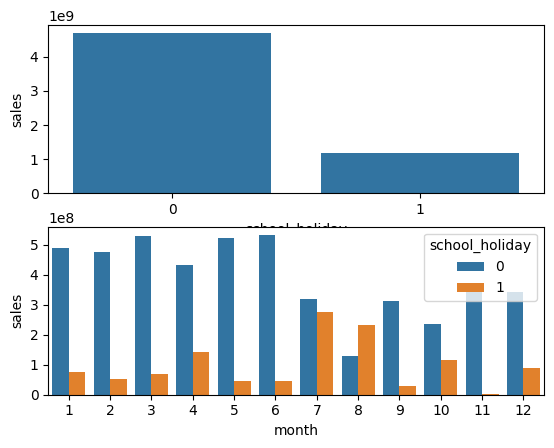

In [46]:
# ── Gráfico 1: Vendas totais — feriado escolar vs dia normal ─
# Agrupa e soma as vendas por indicador de feriado escolar
# (0 = dia normal | 1 = feriado escolar)
# permite comparar o volume total de vendas entre os dois grupos
aux1 = df4[['school_holiday','sales']].groupby('school_holiday').sum().reset_index()
plt.subplot(2,1,1)
sns.barplot(x='school_holiday', y='sales', data= aux1)

# ── Gráfico 2: Vendas por mês separadas por feriado escolar ──
# Agrupa as vendas por mês e por indicador de feriado escolar
# o hue='school_holiday' separa as barras por grupo dentro de cada mês
# permite identificar em quais meses os feriados escolares
# têm maior ou menor impacto nas vendas
aux2 = df4[['month','school_holiday','sales']].groupby(['month', 'school_holiday']).sum().reset_index()
plt.subplot(2,1,2)
sns.barplot(x='month', y='sales', hue='school_holiday', data= aux2)

In [47]:
############ tentar refazer as hipóteses

### 4.2.1. Resumo das Hipóteses

In [48]:
# Lista com os resultados de cada hipótese analisada
# cada sublista contém: [hipótese, conclusão, relevância para o modelo]
tab = [['Hipoteses', 'Conclusao', 'Relevancia'],
       ['H1', 'Falsa', 'Baixa'],
       ['H2', 'Falsa', 'Media'],
       ['H3', 'Falsa', 'Media'],
       ['H4', 'Falsa', 'Baixa'],
       ['H5', '-','-'],       # hipótese não avaliada ainda
       ['H6', 'Falsa', 'Baixa'],
       ['H7', 'Falsa', 'Media'],
       ['H8', 'Falsa', 'Alta'],
       ['H9', 'Falsa', 'Alta'],
       ['H10', 'Verdadeira', 'Alta'],
       ['H11', 'Verdadeira', 'Alta'],
       ['H12', 'Verdadeira', 'Baixa'],
      ]

# tabulate formata a lista como uma tabela legível no terminal
# headers='firstrow' indica que a primeira sublista é o cabeçalho
print(tabulate(tab, headers='firstrow'))

Hipoteses    Conclusao    Relevancia
-----------  -----------  ------------
H1           Falsa        Baixa
H2           Falsa        Media
H3           Falsa        Media
H4           Falsa        Baixa
H5           -            -
H6           Falsa        Baixa
H7           Falsa        Media
H8           Falsa        Alta
H9           Falsa        Alta
H10          Verdadeira   Alta
H11          Verdadeira   Alta
H12          Verdadeira   Baixa


## 4.3 Análise Multivariada

### 4.3.1. Numerical Attributes

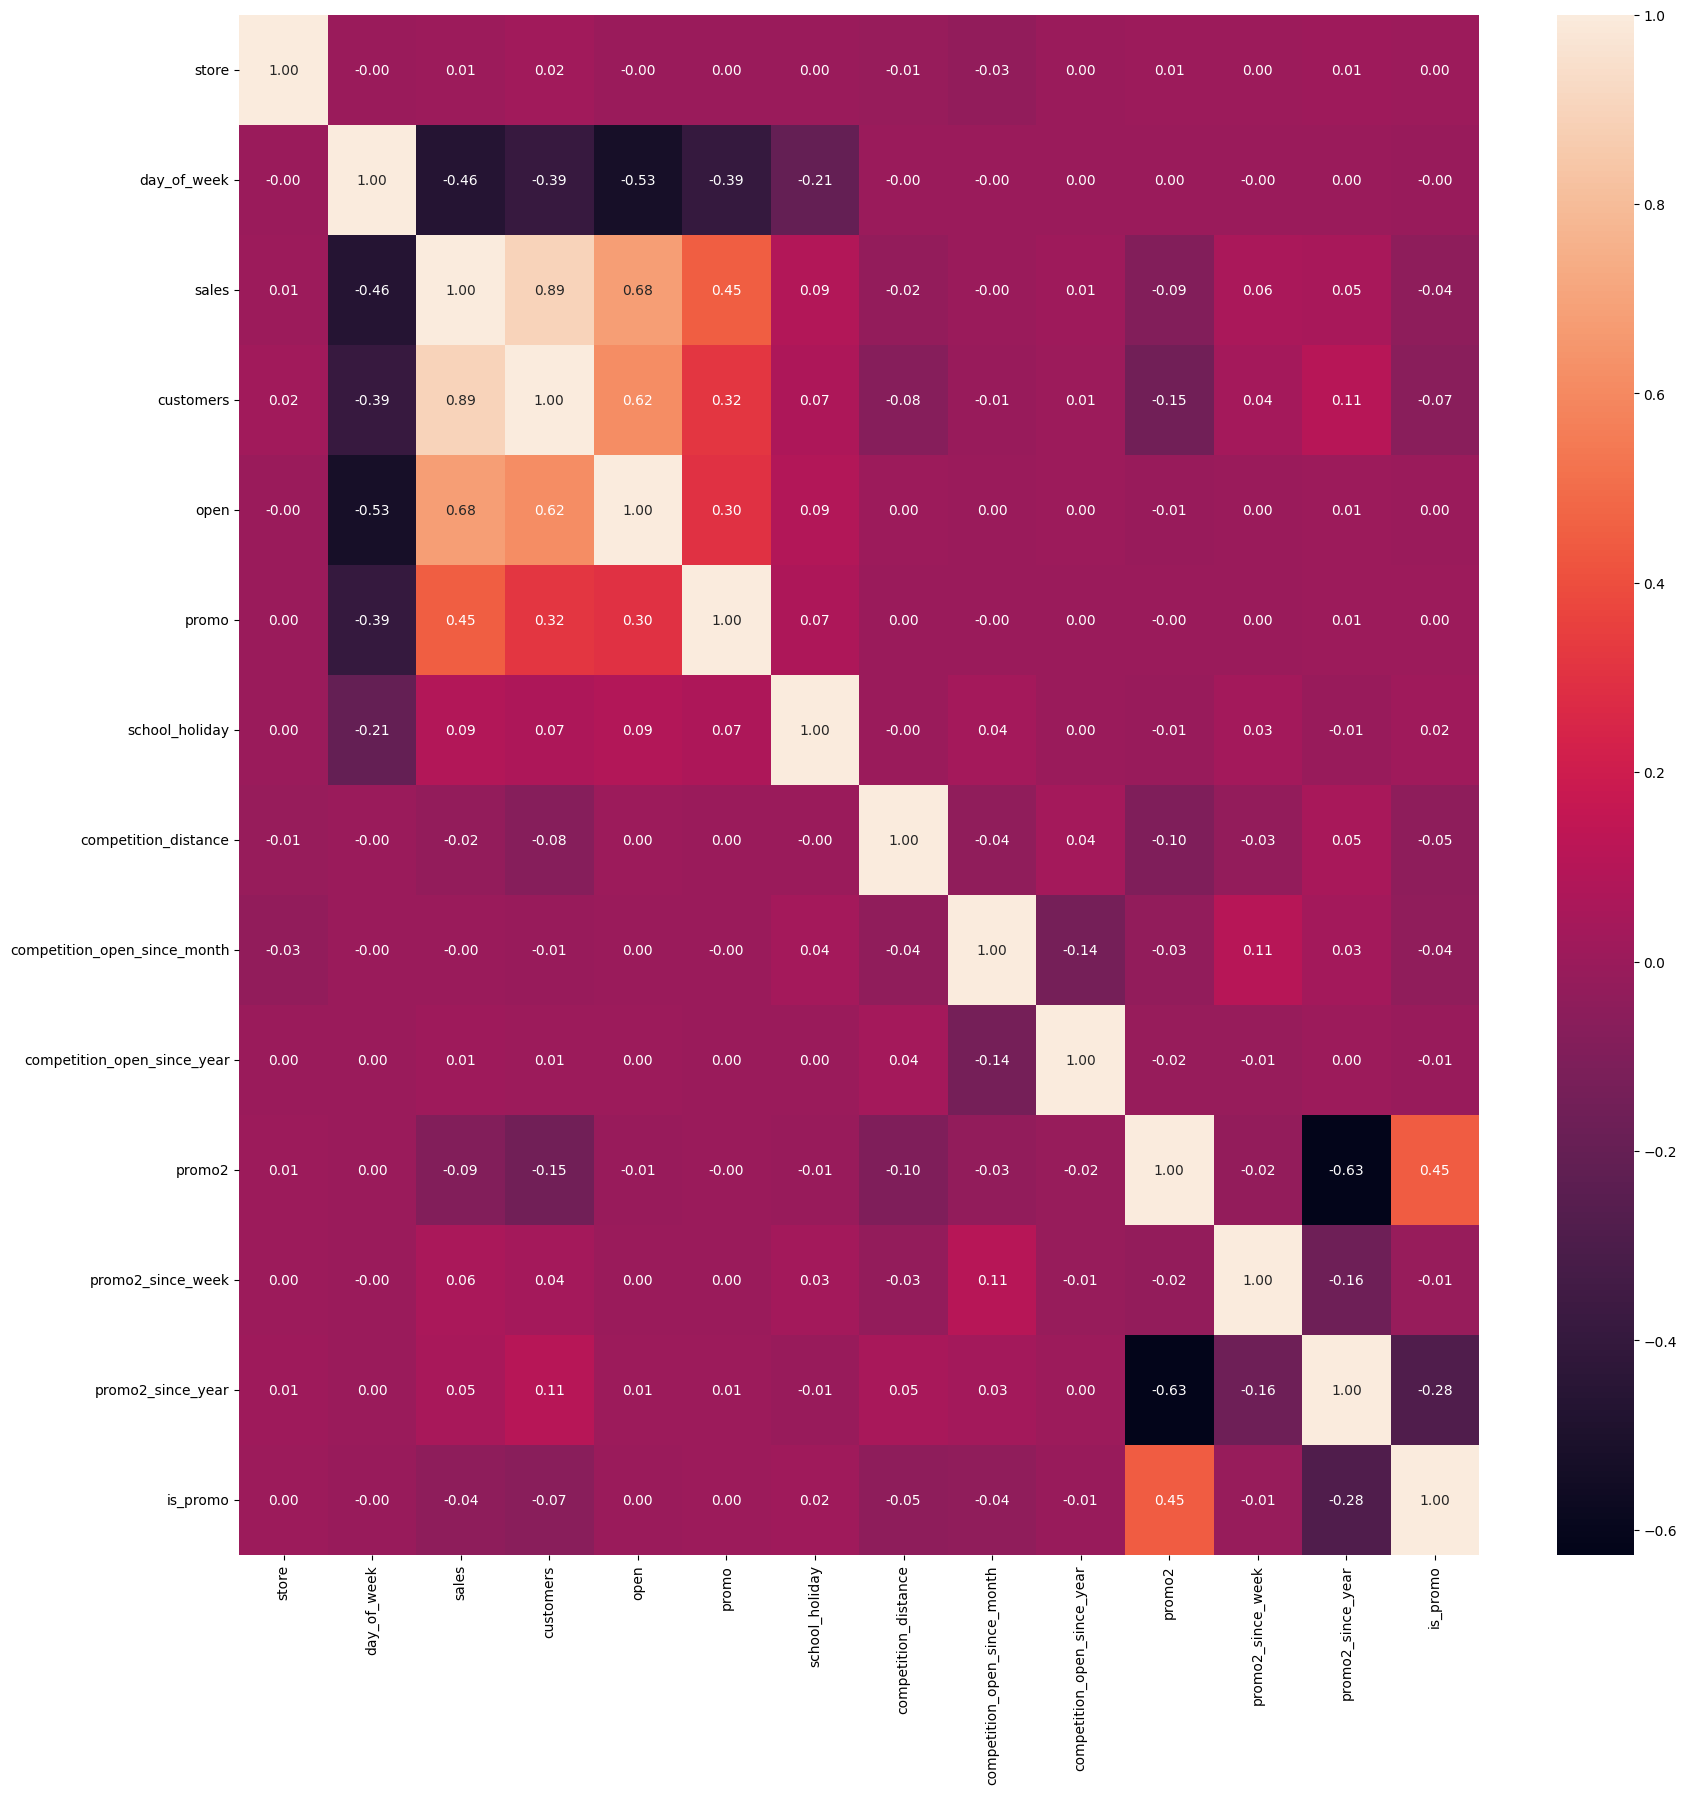

In [49]:
plt.figure(figsize=(20,20))
# Calcula a correlação de Pearson entre todas as variáveis numéricas
# resultado é uma matriz onde cada célula indica a força da relação
correlation = num_attributes.corr(method='pearson')
# Plota a matriz de correlação como heatmap
# annot=True  → exibe o valor numérico dentro de cada célula
# fmt=".2f"   → formata os valores com 2 casas decimais
sns.heatmap(correlation, annot=True, fmt=".2f")

plt.show()

### 4.3.2 Categorical Attributes

In [50]:
a.head()

,store,day_of_week,date,sales,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,...,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
63559,5,4,2015-06-04,5807,1,public_holiday,0,a,basic,29910.0,...,0,2015,6,4,23,2015-22,2015-04-01,2,2015-06-01,0
63560,6,4,2015-06-04,5749,1,public_holiday,0,a,basic,310.0,...,0,2015,6,4,23,2015-22,2013-12-01,18,2015-06-01,0
63609,55,4,2015-06-04,5984,1,public_holiday,0,a,basic,720.0,...,0,2015,6,4,23,2015-22,2004-11-01,128,2015-06-01,0
63611,57,4,2015-06-04,9301,1,public_holiday,0,d,extended,420.0,...,0,2015,6,4,23,2015-22,2014-06-01,12,2015-06-01,0
63614,60,4,2015-06-04,10399,1,public_holiday,0,d,extended,5540.0,...,0,2015,6,4,23,2015-22,2009-10-01,69,2015-06-01,0


<Axes: >

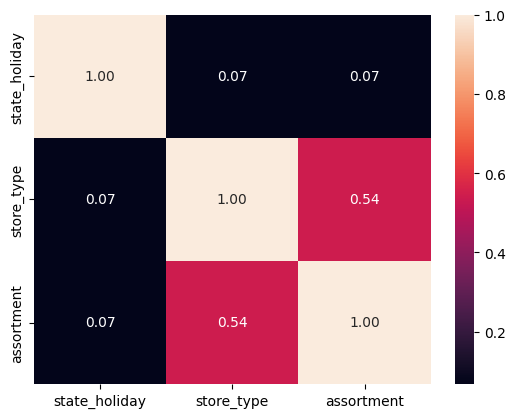

In [51]:
# Seleciona apenas as colunas categóricas do DataFrame
# 'str' substitui 'object' para evitar warning no pandas moderno
a = df4.select_dtypes(include='str')

# ── Cálculo do Cramér's V entre todas as variáveis categóricas ──
# Cramér's V mede a força da associação entre duas variáveis categóricas
# varia de 0 a 1:
# 0.0 → sem associação
# 1.0 → associação perfeita
# diferente de Pearson, não indica direção — apenas força da relação

# Correlações envolvendo state_holiday
a1 = cramer_v(a['state_holiday'], a['state_holiday'])  # sempre 1.0 — variável com ela mesma
a2 = cramer_v(a['state_holiday'], a['store_type'])
a3 = cramer_v(a['state_holiday'], a['assortment'])

# Correlações envolvendo store_type
a4 = cramer_v(a['store_type'], a['state_holiday'])
a5 = cramer_v(a['store_type'], a['store_type'])        # sempre 1.0 — variável com ela mesma
a6 = cramer_v(a['store_type'], a['assortment'])

# Correlações envolvendo assortment
a7 = cramer_v(a['assortment'], a['state_holiday'])
a8 = cramer_v(a['assortment'], a['store_type'])
a9 = cramer_v(a['assortment'], a['assortment'])        # sempre 1.0 — variável com ela mesma

# ── Monta a matriz de correlação como DataFrame ─────────────
# organiza os valores calculados em formato de matriz quadrada
# set_index usa os próprios nomes das colunas como índice
d = pd.DataFrame({'state_holiday': [a1, a2, a3],
                  'store_type':    [a4, a5, a6],
                  'assortment':    [a7, a8, a9]
                 })
d = d.set_index(d.columns)

# ── Heatmap da matriz de Cramér's V ─────────────────────────
# visualiza a força das associações entre as variáveis categóricas
# annot=True  → exibe o valor numérico dentro de cada célula
# fmt=".2f"   → formata os valores com 2 casas decimais
sns.heatmap(d, annot=True, fmt=".2f")

# 5.0 DATA PREPARATION

In [92]:
df5 = df4.copy()

## 5.1 Normalizacao

In [53]:
# analisando o item 4.1.2 Numerical Variable identificou-se que as variáveis 
# numéricas não se enquandrão em distribuição normal, e optou-se a utilizar o Rescaling

## 5.2 Rescaling

In [ ]:
rs = RobustScaler()
mms = MinMaxScaler()

# competition_distance
df5['competition_distance'] = rs.fit_transform(df5[['competition_distance']].values )
pickle.dump(rs, open('parameter/competition_distance_scaler.pkl', 'wb'))

# competition_time_month
df5['competition_time_month'] = rs.fit_transform(df5[['competition_time_month']].values )
pickle.dump(rs, open('parameter/competition_time_month_scaler.pkl', 'wb'))

# promo_time_week
df5['promo_time_week'] = mms.fit_transform(df5[['promo_time_week']].values )
pickle.dump(mms, open('parameter/promo_time_week_scaler.pkl', 'wb'))


# year
df5['year'] = mms.fit_transform(df5[['year']].values )
pickle.dump(mms, open('parameter/year_scaler.pkl', 'wb'))


## 5.3 Transformacao

### 5.3.1 Encoding

In [94]:
# state_holiday - ONE HOT ENCODING
df5 = pd.get_dummies(df5, prefix=['state_holiday'], columns = ['state_holiday'], dtype = int )

# store_type - LABEL ENCODER
le = LabelEncoder()
df5['store_type'] = le.fit_transform(df5['store_type'])
pickle.dump(le, open('parameter/store_type_scaler.pkl', 'wb'))

# assortment - ORDINAL ENCONDING # dá pra fazer o projeto ppor dois meios com sklearn ou map(dict)
oe = OrdinalEncoder(categories=[['basic', 'extended', 'extra']])
df5['assortment'] = oe.fit_transform(df5[['assortment']])
pickle.dump(oe, open('parameter/assortment_scaler.pkl', 'wb'))

# assortment_dict = {'basic': 1, 'extended': 2, 'extra': 3}
# df5['assortment'] = df5['assortment'].map(assortment_dict)

# Dá para usar o target encoding para as transformações, vamos testar no próximo ciclo do CRISP

### 5.3.2 Response Variable Transformation

In [56]:
df5['sales'] = np.log1p( df5['sales'])

### 5.3.3. Nature Transformation

In [57]:
# transformando variáveis de natureza cíclica
# Day
df5['day_sin'] = df5[ 'day' ].apply( lambda x: np.sin( x * ( 2. * np.pi/30 ) ) )
df5['day_cos'] = df5[ 'day' ].apply( lambda x: np.cos( x * ( 2. * np.pi/30 ) ) )

# day_of_week
df5['day_of_week_sin'] = df5[ 'day_of_week' ].apply( lambda x: np.sin( x * ( 2. * np.pi/7 ) ) )
df5['day_of_week_cos'] = df5[ 'day_of_week' ].apply( lambda x: np.cos( x * ( 2. * np.pi/7 ) ) )

# month
df5['month_sin'] = df5[ 'month' ].apply( lambda x: np.sin( x * ( 2. * np.pi/12 ) ) )
df5['month_cos'] = df5[ 'month' ].apply( lambda x: np.cos( x * ( 2. * np.pi/12 ) ) )

# week_of_year
df5['week_of_year_sin'] = df5[ 'week_of_year' ].apply( lambda x: np.sin( x * ( 2. * np.pi/52 ) ) )
df5['week_of_year_cos'] = df5[ 'week_of_year' ].apply( lambda x: np.cos( x * ( 2. * np.pi/52 ) ) )

# 6.0 FEATURE SELECTION

In [58]:
df6 = df5.copy()

## 6.1 Split dataframe into training and test dataset

In [59]:
# Apagar variáveis originais que serviram para derivar
cols_drop = ['week_of_year', 'day', 'month', 'day_of_week', 'promo_since', 'competition_since', 'year_week', 'promo_interval']
df6 = df6.drop(cols_drop, axis=1)

In [60]:
# Dividir dados de treino e test
# Foi escolhida as últimas 6 semanas para dados de teste, então foi usada a forma datetime.timedelta
# com os dados multiplicando 6 semanas por 7 dias (42 dias ) e retirando esses 42 dias do dataset
# para identificar a partir de qual data o dataset será dividido
df6[['store', 'date']].groupby('store').max().reset_index()['date'][0] - datetime.timedelta( days=6*7 )

Timestamp('2015-06-19 00:00:00')

In [61]:
#separando os dataset
#training dataset
X_train = df6[df6['date'] < '2015-06-19']
y_train = X_train['sales']

#test dataset
X_test = df6[df6['date'] >= '2015-06-19']
y_test = X_test['sales']

print('Training Min Date: {}'.format(X_train['date'].min() ) )
print('Training Max Date: {}'.format(X_train['date'].max() ) )

print('\nTest Min Date: {}'.format(X_test['date'].min() ) )
print('Test Max Date: {}'.format(X_test['date'].max() ) )

Training Min Date: 2013-01-01 00:00:00
Training Max Date: 2015-06-18 00:00:00

Test Min Date: 2015-06-19 00:00:00
Test Max Date: 2015-07-31 00:00:00


## 6.2 Boruta as Feature Selector

In [62]:
df6

,store,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,...,state_holiday_public_holiday,state_holiday_regular_day,day_sin,day_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,week_of_year_sin,week_of_year_cos
0,1,2015-07-31,8.568646,1,1,2,0.0,-0.170968,9,2008,...,0,1,0.207912,0.978148,-0.974928,-0.222521,-0.5,-0.866025,-0.568065,-0.822984
1,2,2015-07-31,8.710290,1,1,0,0.0,-0.283871,11,2007,...,0,1,0.207912,0.978148,-0.974928,-0.222521,-0.5,-0.866025,-0.568065,-0.822984
2,3,2015-07-31,9.025816,1,1,0,0.0,1.903226,12,2006,...,0,1,0.207912,0.978148,-0.974928,-0.222521,-0.5,-0.866025,-0.568065,-0.822984
3,4,2015-07-31,9.546527,1,1,2,1.0,-0.275806,9,2009,...,0,1,0.207912,0.978148,-0.974928,-0.222521,-0.5,-0.866025,-0.568065,-0.822984
4,5,2015-07-31,8.481151,1,1,0,0.0,4.448387,4,2015,...,0,1,0.207912,0.978148,-0.974928,-0.222521,-0.5,-0.866025,-0.568065,-0.822984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2013-01-01,8.124447,0,1,1,0.0,-0.351613,9,2006,...,1,0,0.207912,0.978148,0.974928,-0.222521,0.5,0.866025,0.120537,0.992709
1016827,733,2013-01-01,9.284148,0,1,1,2.0,-0.237097,10,1999,...,1,0,0.207912,0.978148,0.974928,-0.222521,0.5,0.866025,0.120537,0.992709
1016863,769,2013-01-01,8.524367,0,1,1,2.0,-0.240323,1,2013,...,1,0,0.207912,0.978148,0.974928,-0.222521,0.5,0.866025,0.120537,0.992709
1017042,948,2013-01-01,8.410053,0,1,1,2.0,-0.145161,1,2013,...,1,0,0.207912,0.978148,0.974928,-0.222521,0.5,0.866025,0.120537,0.992709


In [63]:
# ALGORITIMO BORUTA APLICADO E COMENTADO PARA NÃO RODAR DE NOVO
# #training and test dataset for Boruta
# X_train_n = X_train.drop(['date','sales'], axis=1).values
# y_train_n = y_train.values.ravel()

# #define RandomForestRegressor
# rf = RandomForestRegressor( n_estimators=100, n_jobs=-1, max_depth=5, random_state=42)

# #define boruta
# boruta = BorutaPy(rf, n_estimators=100, max_iter=30, verbose=2, random_state=42).fit(X_train_n, y_train_n)

### 6.2.1 Best Features from boruta

In [64]:
# cols_selected = boruta.support_.tolist()

# # best features
# X_train_fs = X_train.drop(['date', 'sales'], axis=1)
# cols_selected_boruta = X_train_fs.iloc[:, cols_selected].columns.to_list()

# cols_not_selected_boruta = list(np.setdiff1d(X_train_fs.columns, cols_selected_boruta))

# #agora é preciso voltar na tabela resumo das hipóteses e conferir se as colunas mantidas pelo boruta são as mesmas relevantes pelo na análise exploratória


## 6.3 Manual Feature Selection

In [65]:
#salvando as colunas destacadas pelo Boruta
cols_selected_boruta =[
    'store',
    'promo',
    'store_type',
    'assortment',
    'competition_distance',
    'competition_open_since_month',
    'competition_open_since_year',
    'promo2',
    'promo2_since_week',
    'promo2_since_year',
    'competition_time_month',
    'promo_time_week',
    'day_sin',
    'day_cos',
    'day_of_week_sin',
    'day_of_week_cos',
    'month_sin',
    'month_cos',
    'week_of_year_sin',
    'week_of_year_cos']

# Implementando as colundas 'date' e 'sales' em uma tabela que servirá para dividir o dataframe no crossvalidation
# columns to add
feat_to_add = ['date', 'sales'] #escondi essa célula para conseguir rodar a regressão, a regressão não consegue rodar datetime

#finalfeatures
cols_selected_boruta_full = cols_selected_boruta.copy()
cols_selected_boruta_full.extend(feat_to_add) #escondi essa célula para conseguir rodar a regressão, a regressão não consegue rodar datetime

# 7.0 MACHINE LEARNING MODELLING

In [66]:
# escolhendo as colunas das variáveis categóricas
x_train = X_train[ cols_selected_boruta ]
x_test = X_test[ cols_selected_boruta]

#base de dados para a função Cross_validation
x_training = X_train[ cols_selected_boruta_full ]

## 7.1 Average Model

In [67]:
# ============================================================
# BASELINE — Modelo de média por loja (benchmark)
# ============================================================
# O baseline serve como referência mínima de performance
# Todo modelo de ML treinado deve superar esse resultado
# Se não superar, o modelo não agrega valor real

# ── Prepara o dataset de teste com as vendas reais ──────────
# Copia x_test para não modificar o original
# adiciona a coluna sales (y_test) para calcular a média por loja
aux1 = x_test.copy()
aux1['sales'] = y_test.copy()

# ── Calcula a predição baseline ──────────────────────────────
# Estratégia: para cada loja, prevê sempre a média histórica de vendas
# É o modelo mais simples possível — ignora data, promoção, feriados, etc.
aux2 = aux1[['store', 'sales']].groupby('store').mean().reset_index().rename(columns={'sales': 'predictions'})

# Faz o merge para trazer a média de cada loja de volta ao dataset de teste
# cada linha recebe como previsão a média de vendas da sua respectiva loja
aux1 = pd.merge(aux1, aux2, how='left', on='store')
yhat_baseline = aux1['predictions']

# ── Avalia a performance do baseline ────────────────────────
# np.expm1() reverte a transformação log1p aplicada anteriormente nas vendas
# ml_error() calcula as métricas de erro (MAE, MAPE, RMSE)
# esse resultado será usado como régua para comparar os próximos modelos
baseline_result = ml_error('Average Model', np.expm1(y_test), np.expm1(yhat_baseline))
baseline_result

,Model Name,MAE,MAPE,RMSE
0,Average Model,1354.800353,0.455051,1835.135542


## 7.2 Linear Regression Model

In [68]:
#model
lr_model = LinearRegression()
lr_model.fit( x_train, y_train )

#prediction
yhat_lr = lr_model.predict( x_test )

#performance
lr_result = ml_error( 'Linear Regression', np.expm1(y_test), np.expm1(yhat_lr) ) # np.expm1() reverte a transformação log1p aplicada anteriormente nas vendas
lr_result

,Model Name,MAE,MAPE,RMSE
0,Linear Regression,1861.127229,0.291652,2662.291292


### 7.2.1 Linear Regression Model - Cross Validation

In [69]:
lr_result_cv = cross_validation(x_training, 5, 'Linear Regression', lr_model, verbose=False)
lr_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Linear Regression,2077.72+/-295.95,0.3+/-0.02,2945.54+/-469.14


## 7.3 Linear Regression Regularized Model - Lasso

In [70]:
#model
lasso_model = Lasso( alpha = 0.01)
lasso_model.fit( x_train, y_train )

#prediction
yhat_lasso = lasso_model.predict( x_test )

#performance
lasso_result = ml_error( 'Linear Regression - lasso', np.expm1(y_test), np.expm1(yhat_lasso) ) # np.expm1() reverte a transformação log1p aplicada anteriormente nas vendas
lasso_result

,Model Name,MAE,MAPE,RMSE
0,Linear Regression - lasso,1891.39867,0.289252,2743.459421


### 7.3.1 Lasso - Cross Validation


In [71]:
lasso_result_cv = cross_validation(x_training, 5, 'Lasso Regression', lasso_model, verbose=False)
lasso_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Lasso Regression,2117.99+/-342.73,0.29+/-0.01,3058.17+/-506.07


## 7.4 Random Forest Regressor

In [72]:
# model
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42).fit(x_train, y_train)

#prediction
yhat_rf = rf.predict( x_test )

# Performance
rf_result = ml_error('Random Forest Regressor', np.expm1(y_test), np.expm1(yhat_rf))
rf_result

,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,678.368389,0.099756,1010.694249


### 7.4.1 Random Forest Regressor - Cross Validation


In [73]:
rf_result_cv = cross_validation( x_training, 5, 'Random Forest Regressor', rf, verbose=True )
rf_result_cv


Kfold Number: 5

Kfold Number: 4

Kfold Number: 3

Kfold Number: 2

Kfold Number: 1


,Model Name,MAE CV,MAPE CV,RMSE CV
0,Random Forest Regressor,839.01+/-219.87,0.12+/-0.02,1258.53+/-320.26


## 7.5 XGBoost Regressor

In [74]:
#model
model_xgb = xgb.XGBRegressor(objective = 'reg:squarederror',
                             n_estimators=100, 
                             eta=0.3,
                             max_depth=6,
                             subsample=1.0,
                             colsample_bytree=1.0).fit(x_train, y_train)
#prediction
yhat_xgb = model_xgb.predict( x_test )

# Performance
xgb_result = ml_error('XGBoost Regressor', np.expm1(y_test), np.expm1(yhat_xgb))
xgb_result

,Model Name,MAE,MAPE,RMSE
0,XGBoost Regressor,864.651744,0.129505,1241.956482


### 7.4.1 XGBoost Regressor - Cross Validation


In [75]:
xgb_result_cv = cross_validation( x_training, 5, 'XGBoost Regressor', model_xgb, verbose=True )
xgb_result_cv


Kfold Number: 5

Kfold Number: 4

Kfold Number: 3

Kfold Number: 2

Kfold Number: 1


,Model Name,MAE CV,MAPE CV,RMSE CV
0,XGBoost Regressor,1050.58+/-136.22,0.15+/-0.01,1500.44+/-188.6


## 7.6 Compare Model's Performance

### 7.6.1 Single Performance

In [76]:
modelling_result = pd.concat( [ baseline_result, lr_result, lasso_result, rf_result, xgb_result ])
modelling_result.sort_values( 'RMSE' )

,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,678.368389,0.099756,1010.694249
0,XGBoost Regressor,864.651744,0.129505,1241.956482
0,Average Model,1354.800353,0.455051,1835.135542
0,Linear Regression,1861.127229,0.291652,2662.291292
0,Linear Regression - lasso,1891.398670,0.289252,2743.459421


### 7.6.2 Real Performance - Cross Validation

In [77]:
modelling_result_cv = pd.concat( [ lr_result_cv, lasso_result_cv, rf_result_cv, xgb_result_cv ] )
modelling_result_cv.sort_values( 'RMSE CV' )

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Random Forest Regressor,839.01+/-219.87,0.12+/-0.02,1258.53+/-320.26
0,XGBoost Regressor,1050.58+/-136.22,0.15+/-0.01,1500.44+/-188.6
0,Linear Regression,2077.72+/-295.95,0.3+/-0.02,2945.54+/-469.14
0,Lasso Regression,2117.99+/-342.73,0.29+/-0.01,3058.17+/-506.07


# 8.0 HIPERPARAMETER FINE TUNING

## 8.1 Random Search

In [78]:
import random
import warnings
warnings.filterwarnings('ignore')

In [79]:
param = {'n_estimators': [1500, 1700, 2500, 3000, 3500],
         'eta': [0.01, 0.03],
         'max_depth': [3, 5, 9],
         'subsample': [0.1, 0.5, 0.7],
         'colsample_bytree': [0.3, 0.7, 0.9],
         'min_child_weight': [3, 8, 15] }

MAX_EVAL = 10

In [80]:
## Algorítimo final de otimização de hiperparâmetros usando busca aleatória (Random Search)
# final_result = pd.DataFrame()

# for i in range( MAX_EVAL ):
#     #choose values for parameters randomly
#     hp = { k: random.sample( v, 1 )[0] for k, v in param.items() }

#     #printar os parâmetros usados na iteração
#     print(f'\nIteração {i+1}/{MAX_EVAL}')
#     print(f'Parâmetros: {hp}')

#     #model
#     model_xgb = xgb.XGBRegressor(objective = 'reg:squarederror',
#                                 n_estimators=hp['n_estimators'], 
#                                 eta=hp['eta'],
#                                 max_depth=hp['max_depth'],
#                                 subsample=hp['subsample'],
#                                 colsample_bytree=hp['colsample_bytree'],
#                                 min_child_weight=hp['min_child_weight'])

#     # Performance
#     result = cross_validation(x_training, 5, 'XGBoost Regressor', model_xgb, verbose=False )
#     final_result = pd.concat( [final_result, result] )

# final_result

## 8.2 Final Model

In [81]:
# Os melhores parâmetros encontrados foram:
param_tuned = {
               'n_estimators': 2500,
               'eta': 0.03,
               'max_depth': 9,
               'subsample': 0.1,
               'colsample_bytree': 0.7,
               'min_child_weight': 15}

MAX_EVAL = 10

In [82]:
#model
model_xgb_tuned = xgb.XGBRegressor( objective = 'reg:squarederror',
                                    n_estimators=param_tuned['n_estimators'], 
                                    eta=param_tuned['eta'],
                                    max_depth=param_tuned['max_depth'],
                                    subsample=param_tuned['subsample'],
                                    colsample_bytree=param_tuned['colsample_bytree'],
                                    min_child_weight=param_tuned['min_child_weight']).fit(x_train, y_train)

#prediction
yhat_xgb_tuned = model_xgb_tuned.predict( x_test )

# Performance
xgb_result_tuned = ml_error( 'XGBoost Regressor', np.expm1(y_test), np.expm1(yhat_xgb_tuned ))
xgb_result_tuned

,Model Name,MAE,MAPE,RMSE
0,XGBoost Regressor,653.361648,0.095016,957.53886


In [83]:
# Avaliação do modelo otimizado usando MAPE
mean_percentage_error(np.expm1(y_test), np.expm1(yhat_xgb_tuned) )

np.float64(0.0010975219908864555)

# 9.0 TRADUCAO E INTERPRETACAO DO ERRO

In [84]:
df9 = X_test[cols_selected_boruta_full]

#rescale
df9['sales'] =np.expm1(df9['sales'])
df9['predictions'] = np.expm1(yhat_xgb_tuned)

## 9.1 Busines Performance

In [85]:
# sum of predictions
df91 = df9[['store','predictions']].groupby('store').sum().reset_index()

# MAE and MAPE por loja
df9_aux1 = df9[['store', 'sales', 'predictions']].groupby('store').apply( lambda x: mean_absolute_error(x['sales'], x['predictions'] ) ).reset_index().rename(columns={0:'MAE'})
df9_aux2 = df9[['store', 'sales', 'predictions']].groupby('store').apply( lambda x: mean_absolute_percentage_error(x['sales'], x['predictions'] ) ).reset_index().rename(columns={0:'MAPE'})

# Merge dos resultados
df9_aux3 = pd.merge( df9_aux1, df9_aux2, how='inner', on='store' )
df92 = pd.merge(df91, df9_aux3, how='inner', on='store' )

#cenários
df92['worst_scenario'] = df92['predictions'] - df92['MAE']
df92['best_scenario'] = df92['predictions'] + df92['MAE']

# Orders columns
df92 = df92[['store', 'predictions', 'worst_scenario', 'best_scenario', 'MAE', 'MAPE']]

In [86]:
df92.sort_values('MAPE', ascending=False ).head()

,store,predictions,worst_scenario,best_scenario,MAE,MAPE
291,292,105408.75000,102056.606522,108760.893478,3352.143478,0.567864
908,909,235457.15625,227883.456925,243030.855575,7573.699325,0.510914
594,595,355106.43750,350400.855086,359812.019914,4705.582414,0.321595
875,876,197076.75000,193071.972784,201081.527216,4004.777216,0.298192
549,550,241539.87500,240208.835185,242870.914815,1331.039815,0.259633


<Axes: xlabel='store', ylabel='MAPE'>

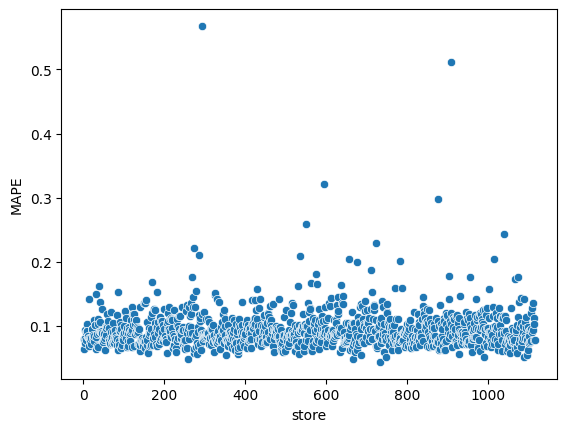

In [87]:
sns.scatterplot(x='store', y='MAPE', data=df92)

## 9.2 Total Performance

In [88]:
df93 = df92[['predictions', 'worst_scenario', 'best_scenario']].apply(lambda x: np.sum(x), axis=0).reset_index().rename(columns={'index':'scenario', 0:'values'})
df93['values'] = df93['values'].map('R${:,.2f}'.format)
df93

,scenario,values
0,predictions,"R$284,080,096.00"
1,worst_scenario,"R$283,347,673.62"
2,best_scenario,"R$284,812,545.82"


## 9.3 Machine Learning Performance

In [89]:
df9['error'] = df9['sales']-df9['predictions']
df9['error_rate'] = df9['predictions']/df9['sales']


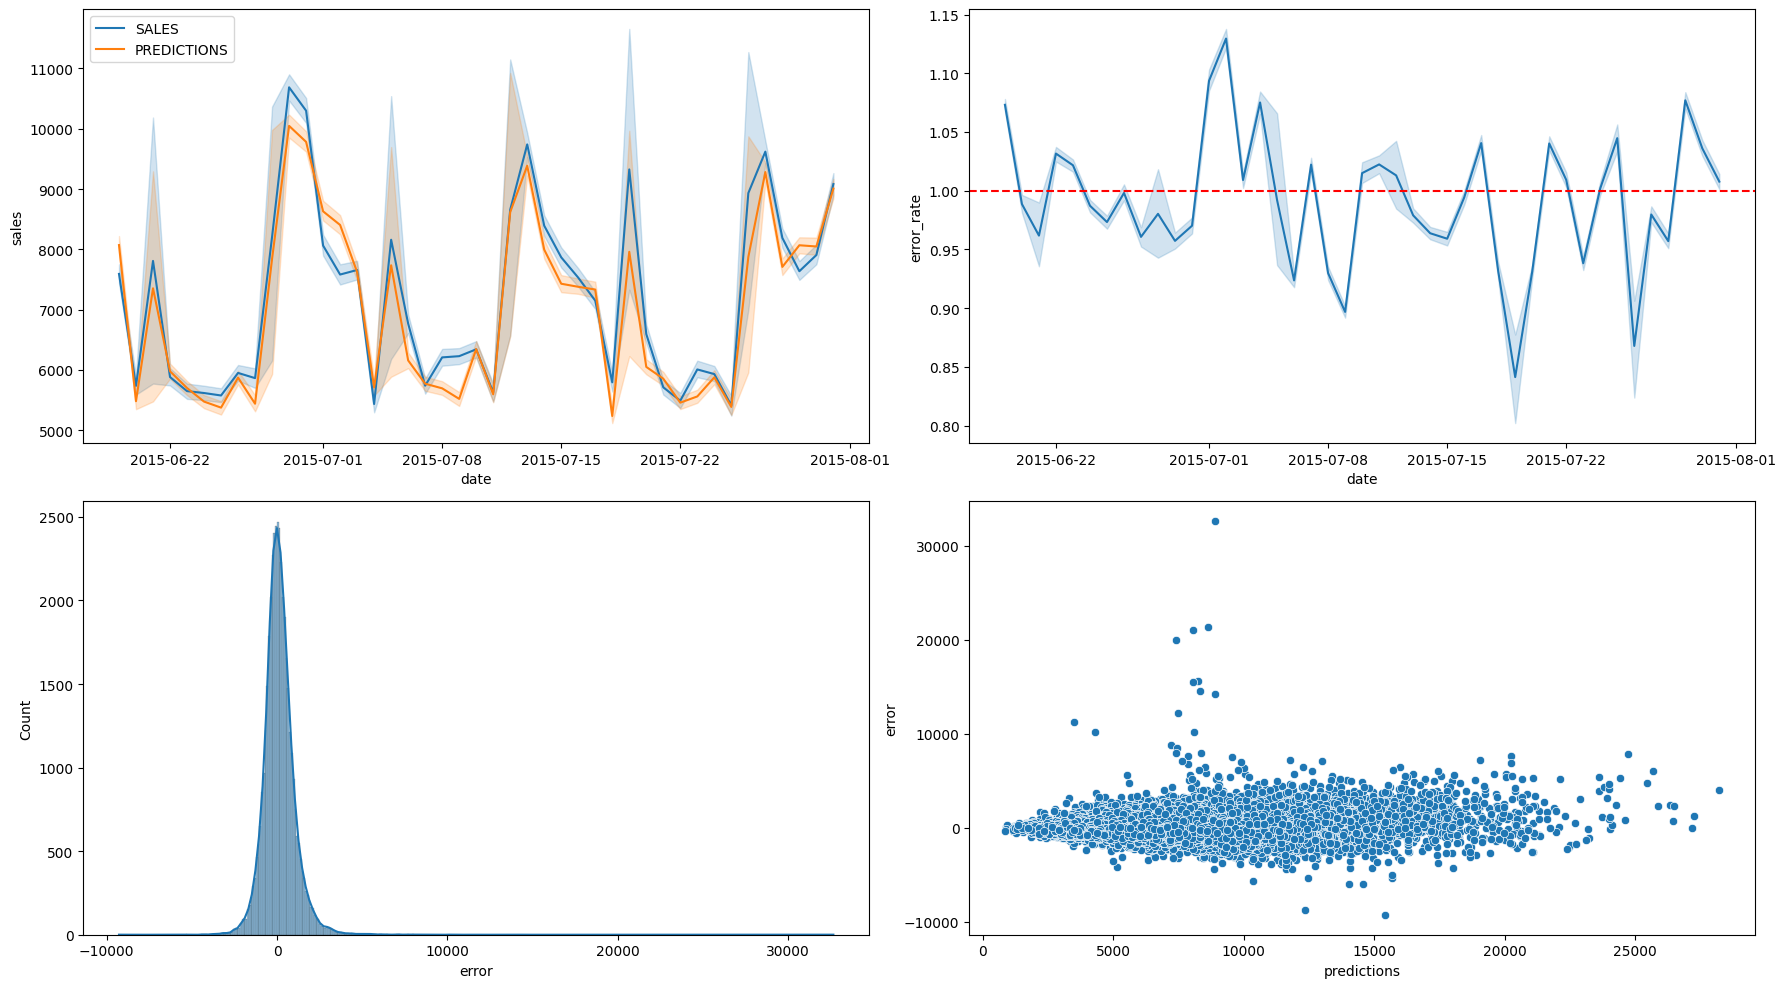

In [90]:
plt.figure(figsize=(18, 10))
plt.subplot(2,2,1)
sns.lineplot(x='date', y='sales', data=df9, label='SALES')
sns.lineplot(x='date', y='predictions', data=df9, label='PREDICTIONS')

plt.subplot(2,2,2)
sns.lineplot(x='date', y='error_rate', data=df9)
plt.axhline(1, color='red', linestyle='--')  # linha de referência para erro de 100%

plt.subplot(2, 2, 3)
sns.histplot(df9['error'], kde=True)

plt.subplot(2,2,4)
sns.scatterplot(x='predictions', y='error', data=df9)

plt.tight_layout()
plt.show()

# 10.0 DEPLOY MODEL TO PRODUCTION

In [91]:
# Modelo final com os melhores hiperparâmetros encontrado, pronto para ser salvo e colocado em produção
pickle.dump(model_xgb_tuned, open('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ds_em_producao_main/model_rossman.pkl', 'wb'))

## 10.1 Rosmann Class

In [ ]:
class Rossmann( object ):
    def __init__( self ):
       self.competition_distance_scaler   = pickle.load( open('parameter/competition_distance_scaler.pkl', 'rb'))
       self.competition_time_month_scaler = pickle.load( open('parameter/competition_time_month_scaler.pkl', 'rb'))
       self.promo_time_week_scaler        = pickle.load( open('parameter/promo_time_week_scaler.pkl', 'rb'))
       self.year_scaler                   = pickle.load( open('parameter/year_scaler.pkl', 'rb'))
       self.store_type_scaler             = pickle.load( open('parameter/store_type_scaler.pkl', 'rb'))
       self.assortment_scaler             = pickle.load( open('parameter/assortment_scaler.pkl', 'rb'))

    def data_cleaning( self, df1 ):
        ## 1.1 Rename columns
        cols_old = [['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
                    'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
                    'CompetitionDistance', 'CompetitionOpenSinceMonth',
                    'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
                    'Promo2SinceYear', 'PromoInterval']]

        snakecase = lambda x: inflection.underscore( x )
        cols_new = list(map(snakecase, cols_old[0]))

        #rename
        df1.columns = cols_new

        ## 1.3 Data Types
        #transformou 'date' em datetime e verificou os tipos das colunas
        df1['date']= pd.to_datetime(df1['date'])

        ## 1.5 Fillout NA
        # competition_distance
        #pegar a coluna competition_distance
        #verificar se tem valor nulo
        #se tiver valor nulo, substituir por 200000.0 (para simular que a loja não tem concorrência próxima)
        #se não tiver valor nulo, manter o valor da coluna
        df1['competition_distance'] = df1['competition_distance'].apply(lambda x: 200000.0 if math.isnan(x) else x)

        # competition_open_since_month - substituir os valores nulos pelo mês da data da linha para não ter valores nulos
        #pegar a coluna competition_open_since_month
        #verificar se tem valor nulo
        #se tiver valor nulo, substituir pelo valor do mês da data da linha 
        #se não tiver valor nulo, manter o valor da coluna
        df1['competition_open_since_month'] = df1.apply(lambda x: x['date'].month if math.isnan(x['competition_open_since_month']) else x['competition_open_since_month'], axis=1)

        # competition_open_since_year
        df1['competition_open_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['competition_open_since_year']) else x['competition_open_since_year'], axis=1)

        # promo2_since_week
        df1['promo2_since_week'] = df1.apply(lambda x: x['date'].week if math.isnan(x['promo2_since_week']) else x['promo2_since_week'], axis=1)

        #promo2_since_year
        df1['promo2_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['promo2_since_year']) else x['promo2_since_year'], axis=1)

        # promo_interval
        #transformou os valores nulos da coluna promo_interval em zero, para não ter valor nulo
        #se a coluna promo_interval for igual a 0, então is_promo é igual a 0
        #se a coluna month_map estiver presente na coluna promo_interval, então is_promo é igual a 1
        #se não, is_promo é igual a 0
        #criou uma coluna nova chamda is_promo, que indica se a loja está em promoção ou não, com base na coluna promo_interval e no mês da data da linha
        month_map ={ 1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec' }
        df1['promo_interval']=df1['promo_interval'].fillna(0)#atualizei o código, o .fillna(0, inplace=True) não funcionou bem então usei o .fillna(0) e atribui o resultado para a própria coluna promo_interval
        df1['month_map'] = df1['date'].dt.month.map(month_map)
        df1['is_promo']= df1[['promo_interval', 'month_map']].apply(lambda x: 0 if x['promo_interval'] == 0 else 1 if x['month_map'] in x['promo_interval'].split(',') else 0, axis=1)
        
        ## 1.6 Change Types
        # Após preencher os valores nulos, é necessário converter as colunas necessárias para o tipo inteiro, 
        # para evitar problemas futuros na análise e modelagem dos dados. As colunas que precisam ser convertidas são:
        # competition_open_since_month, competition_open_since_year, promo2_since_week e promo2_since_year.
        df1['competition_open_since_month'] = df1['competition_open_since_month'].astype(int)
        df1['competition_open_since_year'] = df1['competition_open_since_year'].astype(int)
        df1['promo2_since_week'] = df1['promo2_since_week'].astype(int)
        df1['promo2_since_year'] = df1['promo2_since_year'].astype(int)

        return df1

    def feature_engineering( self, df2 ):
        # ── Extração de componentes da data ─────────────────────────
        # Extrai ano, mês, dia e semana a partir da coluna date
        # para permitir análises temporais granulares

        df2['year']  = df2['date'].dt.year   # ano
        df2['month'] = df2['date'].dt.month  # mês (1-12)
        df2['day']   = df2['date'].dt.day    # dia do mês

        # Extraçãoo da semana do ano
        # dt.weekofyear foi descontinuada no pandas 2.x
        # substituta: isocalendar().week (padrão ISO 8601)
        df2['week_of_year'] = df2['date'].dt.isocalendar().week

        # Combinação de ano e semana no formato 'YYYY-WW'
        # útil para agrupamentos e análises semanais
        df2['year_week'] = df2['date'].dt.strftime('%Y-%W')

        # competition since
        # ── Tempo desde abertura do competidor ──────────────────────
        # Une as colunas competition_open_since_year e competition_open_since_month
        # em uma única data (dia fixado em 1) usando datetime.datetime
        df2['competition_since'] = df2.apply(lambda x: datetime.datetime(year=x['competition_open_since_year'], month = x['competition_open_since_month'], day=1 ), axis=1)

        # Calcula quantos meses se passaram desde a abertura do competidor
        # divide a diferença de datas por 30 para converter em meses
        df2['competition_time_month'] = ((df2['date'] - df2['competition_since'])/30).apply(lambda x: x.days).astype(int)

        # promo since
        # ── Tempo desde início da promoção extendida (promo2) ───────
        # Une promo2_since_year e promo2_since_week no formato 'YYYY-WW'
        # para reconstruir a data de início da promoção
        df2['promo_since'] = df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str)

        # Converte a string 'YYYY-WW' para datetime
        # o sufixo '-1' ancora a data na segunda-feira da semana
        # subtrai 7 dias para alinhar ao início real da semana da promoção
        df2['promo_since'] = df2['promo_since'].apply(lambda x: datetime.datetime.strptime(x + '-1', '%Y-%W-%w') - datetime.timedelta(days=7))

        # Calcula quantas semanas se passaram desde o início da promoção
        # valores positivos = promoção ativa | valores negativos = antes da promoção
        df2['promo_time_week'] = ((df2['date'] - df2['promo_since'])/7).apply(lambda x: x.days).astype(int)

        # ── Decodificação de variáveis categóricas ──────────────────
        # Traduz os códigos originais para descrições legíveis
        # facilitando interpretação e análise exploratória

        # assortment: a=basic | b=extra | c=extended
        # assortment
        df2['assortment'] = df2['assortment'].apply(lambda x: 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended')


        # state_holiday: a=feriado público | b=páscoa | c=natal | 0=dia normal
        df2['state_holiday']=df2['state_holiday'].apply(lambda x: 'public_holiday' if x == 'a' else 'easter_holiday' if x == 'b' else 'christmas' if x == 'c' else 'regular_day')
        
        # 3.0 FILTRAGEM DE VARIÁVEIS
        ## 3.1 Filtragem das linhas
        # restrinções de negócio
        df2 = df2[(df2['open'] != 0) & (df2['sales'] > 0)]
        ## 3.2 Seleção das Colunas
        cols_drop = ['customers', 'open', 'month_map']#'promo' foi recolocada no dataset
        df2 = df2.drop(cols_drop, axis=1)

        return df2
    
    def data_preparation( self, df5):
            
        # analisando o item 4.1.2 Numerical Variable identificou-se que as variáveis 
        # numéricas não se enquandrão em distribuição normal, e optou-se a utilizar o Rescaling
        ## 5.2 Rescaling
        

        # competition_distance
        df5['competition_distance'] = self.competition_distance_scaler.fit_transform(df5[['competition_distance']].values )


        # competition_time_month
        df5['competition_time_month'] = self.competition_time_month_scaler.fit_transform(df5[['competition_time_month']].values )
        
        # promo_time_week
        df5['promo_time_week'] = self.promo_time_week_scaler.fit_transform(df5[['promo_time_week']].values )

        # year
        df5['year'] = self.year_scaler.fit_transform(df5[['year']].values )

        ## 5.3 Transformacao
        ### 5.3.1 Encoding
        # state_holiday - ONE HOT ENCODING
        df5 = pd.get_dummies(df5, prefix=['state_holiday'], columns = ['state_holiday'], dtype = int )

        # store_type - LABEL ENCODER
        df5['store_type'] = self.store_type_scaler.fit_transform(df5['store_type'])
        
        # assortment - ORDINAL ENCONDING # dá pra fazer o projeto ppor dois meios com sklearn ou map(dict)
        df5['assortment'] = self.assortment_scaler.fit_transform(df5[['assortment']])

        ### 5.3.3. Nature Transformation
        # transformando variáveis de natureza cíclica
        # Day
        df5['day_sin'] = df5[ 'day' ].apply( lambda x: np.sin( x * ( 2. * np.pi/30 ) ) )
        df5['day_cos'] = df5[ 'day' ].apply( lambda x: np.cos( x * ( 2. * np.pi/30 ) ) )

        # day_of_week
        df5['day_of_week_sin'] = df5[ 'day_of_week' ].apply( lambda x: np.sin( x * ( 2. * np.pi/7 ) ) )
        df5['day_of_week_cos'] = df5[ 'day_of_week' ].apply( lambda x: np.cos( x * ( 2. * np.pi/7 ) ) )

        # month
        df5['month_sin'] = df5[ 'month' ].apply( lambda x: np.sin( x * ( 2. * np.pi/12 ) ) )
        df5['month_cos'] = df5[ 'month' ].apply( lambda x: np.cos( x * ( 2. * np.pi/12 ) ) )

        # week_of_year
        df5['week_of_year_sin'] = df5[ 'week_of_year' ].apply( lambda x: np.sin( x * ( 2. * np.pi/52 ) ) )
        df5['week_of_year_cos'] = df5[ 'week_of_year' ].apply( lambda x: np.cos( x * ( 2. * np.pi/52 ) ) )

       
        cols_selected =['store', 'promo', 'store_type','assortment', 'competition_distance', 'competition_open_since_month',
            'competition_open_since_year', 'promo2', 'promo2_since_week', 'promo2_since_year', 'competition_time_month',
            'promo_time_week', 'day_sin', 'day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos']

        return df5
    
    

## 10.2 API Handler

In [ ]:
from flask import Flask

app = Flask(__name__)

if __name__ == '__main__':
    app.run( '0.0.0.0' )

## 10.3 API Tester